# RCPSP with Transfer Times and Calendars (RCPSP-TT-cal)

This notebook combines two extensions of the classical RCPSP into a single
model family:
- **Transfer times** (see [`rcpsptt.ipynb`](rcpsptt.ipynb)): when a resource unit
  moves from activity $i$ to activity $j$, at least $\Delta_{ij}$ time units
  must elapse before it is available again.
- **Per-unit calendars** (see [`rcpsp_timeoffs.ipynb`](rcpsp_timeoffs.ipynb)):
  each physical unit has its own step-function availability window.

Because transfer times are tied to **specific physical units** (not aggregate
capacity), all models must keep **unit identity** — there is no
aggregate-capacity shortcut.

> 💡 All solver implementations in this notebook mirror exactly the code in
> the [cpsolve framework](../../../solver/cpsolve/) (`src/cpsolve/problems/rcpsptt_cal/`).
> The instance used throughout is `02.data` from `cpsolve/data/rcpsptt_cal/`.


## Problem Definition

We are given:
- A set of activities $\mathcal{A} = \{0, 1, \dots, n-1\}$ where $0$ is a dummy *source* and $n-1$ a dummy *sink* (both have size 0).
- A set of resource types $\mathcal{K}$; each type $k$ has a pool of physical **units** $\mathcal{U}_k$.
- Each activity $i$ has a **processing time** (size) $p_i$ and requests $q_{i,k}$ units of each type $k$.
- A **precedence graph** $\mathcal{E}$: activity $j$ cannot start before $i$ finishes.
- **Per-unit calendars**: unit $u$ is available only during the intervals described by its step function $\mathcal{F}_u$.
- **Transfer times**: $\Delta_{ij,k}$ is the time a unit of type $k$ needs to travel from activity $i$ to activity $j$.

**Objective**: minimise the makespan $C_{\max} = \operatorname{end}(T_{n-1})$.

### Notation

| Symbol | Meaning |
|--------|--------|
| $\mathcal{A}$ | Activities incl. source $0$ and sink $n-1$ |
| $\mathcal{E}$ | Precedence pairs $(i,j)$: $i$ must finish before $j$ starts |
| $\mathcal{E}^\star$ | Transitive closure of $\mathcal{E}$ |
| $\mathcal{K}$ | Set of resource types |
| $\mathcal{U}_k$ | Physical units of type $k$ |
| $\kappa(u)$ | Type of unit $u$ |
| $p_i$ | Processing time (size) of activity $i$ |
| $q_{i,k}$ | Units of type $k$ requested by activity $i$ |
| $\mathcal{F}_u$ | Step function: $\mathcal{F}_u(t)>0$ iff unit $u$ is available at $t$ |
| $\Delta_{ij,k}$ | Transfer time for type-$k$ unit from activity $i$ to $j$ |
| $T_i$ | Interval variable for activity $i$ |
| $O_{i,u}$ | Optional interval: unit $u$'s block on activity $i$ |


## Data Format & Parsing

The instance format extends the `rcpsp-timeoffs` `.data` layout with a trailing `TRANSFER TIMES` section:

```
<num_tasks> <num_types> <num_units>
per type:    <type_id> <num_units> <unit_id_1> ...
per unit:    <unit_id> <num_steps> <t_1> <v_1> <t_2> <v_2> ...
per task:    <task_id> <size> <num_reqs>   then <type_id> <qty> lines
<num_precedences>   then <pred> <succ> lines
<num_types>         then per type: <type_id> + N rows of N integers
```

Calendar step semantics: value $v$ holds from $t_i$ until $t_{i+1}$; $v>0$ available, $v=0$ unavailable. Task 0 is the dummy source, task $n-1$ the dummy sink.

### Instance file (`02.data`)

Fan-out of three work tasks (A → B, A → C) on two units with fragmented complementary calendars and non-zero transfer times. Every variant produces a different makespan, making this the ideal illustrative instance:

| Variant | Makespan | Transfers used |
|---------|:---:|:---:|
| V1 no-migration / no-interruption | **19** | 1 |
| V2 migration / no-interruption | **15** | 2 |
| V4 no-migration / blocked-interruption | **11** | 1 |
| V3 migration / interruption | **10** | 2 |


In [1]:
with open("../data/rcpsptt_cal/02.data") as f:
    print(f.read())

# =====================================================================
# RCPSP-TT-cal  --  instance "02"  (transfers + all four variants differ)
#
# Fan-out: A (size 4) precedes B (size 2) and C (size 2); each work task
# needs 1 unit of type 0; two units with fragmented complementary calendars.
# Transfer times between the work tasks are non-zero, so whenever a unit is
# reused (A -> B, A -> C, B <-> C) an in-transit block appears.
#
#   Optimal makespan per variant (CPO and OptalCP agree):
#     V1  no-migration / no-interruption      = 19
#     V2  migration    / no-interruption      = 15
#     V4  no-migration / blocked-interruption = 11
#     V3  migration    / interruption         = 10
#
# All four differ (lattice V1 >= V2 >= V3 and V1 >= V4 >= V3) and every
# variant uses at least one transfer (V2/V3 use two), so the Gantt shows
# both the calendar/assignment structure and the resource transfers.
# =====================================================================

# HEADER:

### Parser

The parser below is identical to `_common.parse()` in `src/cpsolve/problems/rcpsptt_cal/_common.py`.

In [2]:
from dataclasses import dataclass
from pathlib import Path
from itertools import combinations, product

HORIZON = 100_000  # safe upper bound for step functions extending to infinity


def _next_line(f):
    """Read next non-empty, non-comment line; return list[int] or None at EOF."""
    while True:
        raw = f.readline()
        if not raw:
            return None
        line = raw.strip()
        if not line or line.startswith('#'):
            continue
        return [int(v) for v in line.split()]


def parse(path):
    """Parse a RCPSP-TT-cal .data file.

    Returns a dict with keys:
      n_tasks, n_types, n_units,
      tasks   : [(task_id, size, ((type_id, qty), ...)), ...]
      types   : [(type_id, (unit_id, ...)), ...]
      units   : [(unit_id, ((time, value), ...)), ...]
      precedences : [(pred, succ), ...]
      transfer: [(type_id, ((row,...), ...)), ...]   NxN matrices
    """
    p = Path(path)
    with p.open() as f:
        n_tasks, n_types, n_units = _next_line(f)
        types = [(d[0], tuple(d[2: 2 + d[1]]))
                 for d in (_next_line(f) for _ in range(n_types))]
        units = [(d[0], tuple((d[2 + 2*i], d[3 + 2*i]) for i in range(d[1])))
                 for d in (_next_line(f) for _ in range(n_units))]
        tasks_list = []
        for _ in range(n_tasks):
            d = _next_line(f)
            tid, size, n_reqs = d[0], d[1], d[2]
            reqs = tuple(tuple(_next_line(f)[:2]) for _ in range(n_reqs))
            tasks_list.append((tid, size, reqs))
        n_prec = _next_line(f)[0]
        precedences = [tuple(_next_line(f)[:2]) for _ in range(n_prec)]
        transfer = []
        head = _next_line(f)
        if head is not None:
            for _ in range(head[0]):
                type_id = _next_line(f)[0]
                matrix = tuple(tuple(_next_line(f)) for _ in range(n_tasks))
                transfer.append((type_id, matrix))
    return dict(
        name=p.stem,
        n_tasks=n_tasks, n_types=n_types, n_units=n_units,
        tasks=tuple(tasks_list), types=tuple(types),
        units=tuple(units), precedences=tuple(precedences),
        transfer=tuple(transfer),
    )


### Helper functions

These helpers mirror `_common.py` from the cpsolve framework exactly.

In [3]:
def transitive_closure(edges, n):
    """All (direct + implied) precedence pairs via Floyd-Warshall."""
    adj = [[False] * n for _ in range(n)]
    for i, j in edges:
        adj[i][j] = True
    for k in range(n):
        ak = adj[k]
        for i in range(n):
            if adj[i][k]:
                ai = adj[i]
                for j in range(n):
                    if ak[j]:
                        ai[j] = True
    return [(i, j) for i in range(n) for j in range(n) if adj[i][j]]


def get_availability(unit_id, time, res_map):
    """Calendar value of a unit at a given time (0 if before first step)."""
    steps = res_map.get(unit_id, ())
    return next((v for t, v in reversed(steps) if time >= t), 0)


def candidate_units(reqs, type_map):
    """All units of any type the task requests."""
    out = []
    for type_id, q in reqs:
        if q > 0:
            out.extend(type_map.get(type_id, ()))
    return out


def build_modes(tasks, type_map):
    """For each task, enumerate all sorted unit-tuples satisfying its reqs."""
    result = {}
    for tid, _, reqs in tasks:
        active = [(t, q) for t, q in reqs if q > 0]
        if not active:
            result[tid] = [()]
            continue
        combos = [list(combinations(type_map[t], q)) for t, q in active]
        result[tid] = (
            [tuple(sorted({r for grp in c for r in grp})) for c in product(*combos)]
            or [()]
        )
    return result


def joint_intensity_steps(unit_ids, res_map, available_value=1):
    """Step list (time, available_value | 0): value>0 iff ALL units available."""
    if not unit_ids:
        return [(0, available_value)]
    times = sorted(
        {0} | {t for uid in unit_ids if uid in res_map for t, _ in res_map[uid]}
    )
    if not times:
        return [(0, available_value)]
    return [
        (t, available_value if all(get_availability(u, t, res_map) > 0
                                   for u in unit_ids) else 0)
        for t in times
    ]


def transition_matrix_for_unit(unit_id, task_ids, unit_to_type, transfer_map):
    """Square matrix of transfer times Delta[a][b] for the given task order on a unit."""
    type_id = unit_to_type.get(unit_id)
    mat = transfer_map.get(type_id, {})
    return [[mat[a][b] if mat else 0 for b in task_ids] for a in task_ids]


def blocks_to_segments(blocks):
    """Turn per-unit blocks (unit, start, end) into contiguous segments.

    Returns list of (start, end, (unit_ids,...)).
    """
    if not blocks:
        return []
    bounds = sorted({b[1] for b in blocks} | {b[2] for b in blocks})
    out = []
    for s, e in zip(bounds, bounds[1:]):
        units = tuple(sorted(u for u, bs, be in blocks if bs <= s < be))
        if not units:
            continue
        if out and out[-1][1] == s and out[-1][2] == units:
            out[-1] = (out[-1][0], e, units)
        else:
            out.append((s, e, units))
    return out


### Load and display the instance

In [4]:
inst = parse("../data/rcpsptt_cal/02.data")

# ── convenience lookups ────────────────────────────────────────────────
type_map    = {tid: units for tid, units in inst['types']}
res_map     = dict(inst['units'])
unit_to_type = {u: tid for tid, units in inst['types'] for u in units}
transfer_map = {tid: mat for tid, mat in inst['transfer']}
SIZE         = {tid: size for tid, size, _ in inst['tasks']}
CAND         = {tid: candidate_units(reqs, type_map)
                for tid, _, reqs in inst['tasks']}
E            = transitive_closure(inst['precedences'], inst['n_tasks'])

def delta(unit_id, i, j):
    """Transfer time of unit_id (its type) from activity i to j."""
    mat = transfer_map.get(unit_to_type.get(unit_id))
    return mat[i][j] if mat else 0

print(f"Instance: {inst['name']}")
print(f"Tasks: {inst['n_tasks']}  Types: {inst['n_types']}  Units: {inst['n_units']}")
print(f"Precedences: {inst['precedences']}")
print(f"Transfer matrix (type 0):")
for row in transfer_map[0]:
    print(' ', list(row))


Instance: 02
Tasks: 5  Types: 1  Units: 2
Precedences: ((0, 1), (1, 2), (1, 3), (2, 4), (3, 4))
Transfer matrix (type 0):
  [0, 0, 0, 0, 0]
  [0, 0, 1, 1, 0]
  [0, 3, 0, 2, 0]
  [0, 3, 2, 0, 0]
  [0, 0, 0, 0, 0]


In [5]:
def print_instance(inst):
    bar = '=' * 75
    print(bar)
    print(f"INSTANCE: {inst['name']}")
    print(f"Dimensions: {inst['n_tasks']} Tasks x {inst['n_types']} Types x {inst['n_units']} Units")
    print(bar)
    for tid, units in inst['types']:
        print(f"  Type {tid}: units {{{', '.join(f'U{u}' for u in units)}}}")
    print()
    print(f"{'Task':<6} {'Dur':<4} {'Requirements':<28} -> Succ")
    print('-' * 75)
    for tid, size, reqs in inst['tasks']:
        succs = [s for p, s in inst['precedences'] if p == tid]
        req_str = ', '.join(f"{q}xType{t}" for t, q in reqs if q > 0) or '-'
        print(f"T{tid:<5} {size:<4} {req_str:<28} {succs if succs else '-'}")
    print()
    print(f"{'Unit':<6} {'Type':<6} Available Windows")
    print('-' * 75)
    for uid, steps in inst['units']:
        windows = []
        for i, (t, v) in enumerate(steps):
            if v > 0:
                end = steps[i + 1][0] if i + 1 < len(steps) else 'inf'
                windows.append(f'[{t}-{end})')
        print(f"U{uid:<5} T{unit_to_type.get(uid, '?'):<5} {' '.join(windows) if windows else '-'}")
    print()
    print('Transfer times (per type, non-zero Delta_{i->j}):')
    for tid, mat in inst['transfer']:
        nz = [(i, j, mat[i][j]) for i in range(len(mat)) for j in range(len(mat)) if mat[i][j] > 0]
        entries = ', '.join(f'T{i}->T{j}={v}' for i, j, v in nz) if nz else '(none)'
        print(f'  Type {tid}: {entries}')
    print(bar)

print_instance(inst)


INSTANCE: 02
Dimensions: 5 Tasks x 1 Types x 2 Units
  Type 0: units {U0, U1}

Task   Dur  Requirements                 -> Succ
---------------------------------------------------------------------------
T0     0    -                            [1]
T1     4    1xType0                      [2, 3]
T2     2    1xType0                      [4]
T3     2    1xType0                      [4]
T4     0    -                            -

Unit   Type   Available Windows
---------------------------------------------------------------------------
U0     T0     [0-1) [3-5) [6-8) [9-11) [12-inf)
U1     T0     [3-4) [6-7) [8-10) [13-inf)

Transfer times (per type, non-zero Delta_{i->j}):
  Type 0: T1->T2=1, T1->T3=1, T2->T1=3, T2->T3=2, T3->T1=3, T3->T2=2


## Visualisation

The Gantt chart below mirrors `src/cpsolve/problems/rcpsptt_cal/viz.py` — a three-layer diagram:

1. **Calendars** panel — green = unit available, white = unavailable
2. **Assignments** panel — coloured task blocks on each unit's lane;
   the calendar breaks inside an assigned block are shaded light gray
3. **Transfer intervals** — gray *"in transit"* blocks between consecutive distinct tasks on the same unit, labelled `Ti→Tj`

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

_TASK_COLORS = [
    'steelblue', 'coral', 'gold', 'mediumpurple', 'darkcyan',
    'sandybrown', 'olivedrab', 'salmon', 'slateblue', 'teal',
]
_BREAK_COLOR    = 'lightgray'
_TRANSFER_COLOR = 'gray'


def _segments_from_assignment(ta):
    """Normalise to [(start, end, [unit_ids])] regardless of encoding.

    Accepts both dict {'id':..,'start':..,'end':..,'resources':..,'segments':..}
    and plain tuples (start, end, [units]) for quick ad-hoc calls.
    """
    if isinstance(ta, dict):
        segs = ta.get('segments') or []
        if segs:
            return [(s['start'], s['end'], list(s.get('resources', [])))
                    for s in segs]
        rs = ta.get('resources') or []
        s, e = ta['start'], ta['end']
        return [(s, e, list(rs))] if e > s else []
    # plain tuple (start, end, units)
    s, e, us = ta
    return [(s, e, list(us))] if e > s else []


def _work_breaks(start, end, units, res_map):
    """Split [start, end) into (sub_start, sub_end, is_working) triples."""
    change_points = {start, end}
    for r in units:
        if r in res_map:
            for t, _ in res_map[r]:
                if start < t < end:
                    change_points.add(t)
    pts = sorted(change_points)
    out = []
    for i in range(len(pts) - 1):
        s, e = pts[i], pts[i + 1]
        working = all(get_availability(r, s, res_map) > 0 for r in units) if units else True
        out.append((s, e, working))
    return out


def _unit_task_spans(schedule_dicts):
    """Per unit: time-ordered list of (task_id, (overall_start, overall_end))."""
    usages = {}
    for ta in schedule_dicts:
        tid = ta['id'] if isinstance(ta, dict) else ta[0]
        for s, e, units in _segments_from_assignment(ta):
            if e <= s:
                continue
            for u in units:
                by_task = usages.setdefault(u, {})
                if tid in by_task:
                    ps, pe = by_task[tid]
                    by_task[tid] = (min(ps, s), max(pe, e))
                else:
                    by_task[tid] = (s, e)
    return {u: sorted(bt.items(), key=lambda kv: kv[1][0])
            for u, bt in usages.items()}


def _transfers_per_unit(inst, schedule_dicts):
    """Per unit: list of (start, end, pred_task, succ_task) transit blocks."""
    out = {}
    for u, order in _unit_task_spans(schedule_dicts).items():
        for (ta, (_, ea)), (tb, (sb, _)) in zip(order, order[1:]):
            if ta == tb:
                continue
            d = delta(u, ta, tb)
            if d > 0:
                start = ea
                out.setdefault(u, []).append((start, min(start + d, sb), ta, tb))
    return out


def visualize(inst, schedule_dicts, *, title='', horizon=None, figsize=(12, 6)):
    """Render a 2-panel Gantt: Calendars + Assignments with transfers.

    `schedule_dicts` is a list of dicts with keys:
      id, start, end,
      resources (optional list[int])  — for no-migration variants
      segments  (optional list[dict]) — for migration variants;
                each segment has start, end, resources.
    """
    try:
        import docplex.cp.utils_visu as visu
    except ImportError:
        visu = None

    # If docplex visu is available, use it; otherwise fall back to matplotlib.
    if visu is not None:
        _visualize_visu(inst, schedule_dicts, title=title,
                        horizon=horizon, figsize=figsize)
    else:
        _visualize_mpl(inst, schedule_dicts, title=title,
                       horizon=horizon, figsize=figsize)


def _visualize_visu(inst, schedule_dicts, *, title, horizon, figsize):
    """docplex.cp.utils_visu-based Gantt (two panels: Calendars + Assignments)."""
    import docplex.cp.utils_visu as visu
    import matplotlib.pyplot as plt

    plt.rcParams['figure.figsize'] = figsize
    if horizon is None:
        sched_end = max((ta['end'] for ta in schedule_dicts if isinstance(ta, dict)),
                        default=0)
        cal_last = max((tt for _, steps in inst['units'] for tt, _ in steps),
                       default=0)
        horizon = max(sched_end, cal_last) + 1

    transfers = _transfers_per_unit(inst, schedule_dicts)

    visu.timeline(origin=0, horizon=horizon)

    # Panel 1 — calendars
    visu.panel('Calendars')
    for uid, steps in inst['units']:
        type_id = unit_to_type.get(uid, '?')
        visu.sequence(name=f'T{type_id}[U{uid}]')
        for i, (t, v) in enumerate(steps):
            next_t = steps[i + 1][0] if i + 1 < len(steps) else horizon + 1
            if v > 0:
                visu.interval(t, next_t, 'lightgreen')

    # Panel 2 — assignments
    visu.panel('Assignments')
    for uid, _ in inst['units']:
        type_id = unit_to_type.get(uid, '?')
        visu.sequence(name=f'T{type_id}[U{uid}]')
        for ta in schedule_dicts:
            tid = ta['id'] if isinstance(ta, dict) else ta[0]
            for seg_start, seg_end, units in _segments_from_assignment(ta):
                if uid not in units:
                    continue
                col = _TASK_COLORS[tid % len(_TASK_COLORS)]
                for sub_s, sub_e, working in _work_breaks(seg_start, seg_end, [uid], res_map):
                    visu.interval(sub_s, sub_e,
                                  col if working else _BREAK_COLOR,
                                  f'T{tid}' if working else '')
        for ts, te, pred, succ in transfers.get(uid, []):
            if te > ts:
                visu.interval(ts, te, _TRANSFER_COLOR, f'T{pred}->T{succ}')

    if title:
        plt.suptitle(title, fontsize=12, fontweight='bold')
    visu.show()
    for ax in plt.gcf().axes:
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()


def _visualize_mpl(inst, schedule_dicts, *, title, horizon, figsize):
    """Pure-matplotlib fallback Gantt (single panel)."""
    n_units = inst['n_units']
    if horizon is None:
        all_ends = [ta['end'] for ta in schedule_dicts if isinstance(ta, dict)]
        horizon = (max(all_ends) + 2) if all_ends else 20

    transfers = _transfers_per_unit(inst, schedule_dicts)
    unit_list = [uid for uid, _ in inst['units']]
    lane = {uid: i for i, uid in enumerate(unit_list)}

    fig, ax = plt.subplots(figsize=figsize)

    # calendar off-periods
    for uid, steps in inst['units']:
        l = lane[uid]
        for i, (t, v) in enumerate(steps):
            end_t = steps[i + 1][0] if i + 1 < len(steps) else horizon
            if v == 0:
                ax.barh(l, end_t - t, left=t, height=0.8,
                        color=_BREAK_COLOR, edgecolor='none', zorder=0)

    # task blocks
    for ta in schedule_dicts:
        tid = ta['id'] if isinstance(ta, dict) else ta[0]
        col = _TASK_COLORS[tid % len(_TASK_COLORS)]
        for seg_start, seg_end, units in _segments_from_assignment(ta):
            for uid in units:
                l = lane.get(uid)
                if l is None:
                    continue
                ax.barh(l, seg_end - seg_start, left=seg_start, height=0.6,
                        color=col, edgecolor='black', zorder=2)
                ax.text((seg_start + seg_end) / 2, l, f'T{tid}',
                        ha='center', va='center', color='white',
                        fontweight='bold', fontsize=8, zorder=3)

    # transfer blocks
    for uid, trans_list in transfers.items():
        l = lane.get(uid)
        if l is None:
            continue
        for ts, te, pred, succ in trans_list:
            if te > ts:
                ax.barh(l, te - ts, left=ts, height=0.6,
                        color=_TRANSFER_COLOR, edgecolor='black', zorder=2)
                ax.text((ts + te) / 2, l, f'T{pred}->T{succ}',
                        ha='center', va='center', color='white',
                        fontsize=7, zorder=3)

    ax.set_yticks(range(n_units))
    ax.set_yticklabels([f'U{uid}' for uid in unit_list])
    ax.set_xlim(0, horizon)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_xlabel('time')
    ax.set_title(title)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    legend = [
        Patch(facecolor=_BREAK_COLOR, label='unit off (calendar)'),
        Patch(facecolor=_TRANSFER_COLOR, label='transfer (in transit)'),
    ]
    ax.legend(handles=legend, loc='upper right', fontsize=8)
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


## Variant 1 — No Migration | No Interruption
(`RCPSP-TT|cal|Cmax`)

Each task is assigned one **fixed set** of units for its entire (uninterrupted) duration. Every assigned unit must be **continuously available** throughout $[s_i, e_i)$. Transfer times appear as a sequence-dependent setup (transition matrix) on each unit's `noOverlap`.

$$
\begin{aligned}
\min \quad & \operatorname{end}(T_{n-1}) && \text{(1)} \\[2mm]
\text{s.t.} \quad
& \operatorname{endBeforeStart}(T_i, T_j) && \forall (i,j)\in\mathcal{E}^\star && \text{(2)} \\[2mm]
& \operatorname{alternative}(T_i,\, [O_{i,u}]_{u\in\mathcal{U}_k},\, q_{i,k}) && \forall i,k && \text{(3)} \\[2mm]
& \operatorname{forbidExtent}(O_{i,u},\, \overline{\mathcal{F}_u}) && \forall i,u && \text{(4)} \\[2mm]
& \operatorname{noOverlap}(\operatorname{seq}_u,\, (\Delta_{ij,\kappa(u)})) && \forall u && \text{(5)}
\end{aligned}
$$

- **(3)**: `alternative(T, [...], cardinality=q)` selects exactly $q$ optional intervals.
- **(4)**: The optional interval is forbidden during unit unavailability.
- **(5)**: Per-unit no-overlap with the transfer-time transition matrix enforces $\Delta$.

### IBM CPO implementation

Mirrors `rcpsptt_cal/cal/models/cpo.py`.

In [7]:
from docplex.cp.model import (
    CpoModel, CpoStepFunction, CpoTransitionMatrix,
    alternative, end_before_start, end_of, forbid_extent,
    interval_var, minimize, no_overlap, sequence_var,
)


def build_step_fn(steps, horizon=HORIZON):
    f = CpoStepFunction()
    for i, (t, v) in enumerate(steps):
        end = steps[i + 1][0] if i + 1 < len(steps) else horizon
        f.set_value(t, end, v)
    return f


avail = {uid: build_step_fn(steps) for uid, steps in inst['units']}
h = HORIZON

mdl = CpoModel(name='rcpsptt_cal_v1_cpo')

T = {tid: interval_var(size=size, name=f'T{tid}')
     for tid, size, _ in inst['tasks']}
O = {(tid, u): interval_var(size=size, optional=True, name=f'T{tid}_U{u}')
     for tid, size, _ in inst['tasks'] for u in CAND[tid]}

mdl.add(minimize(mdl.max([end_of(T[i]) for i in T])))
mdl.add([end_before_start(T[i], T[j]) for i, j in E])

# (3) cardinality alternative per requested type
for tid, _, reqs in inst['tasks']:
    for type_id, qty in reqs:
        if qty > 0 and (units := type_map.get(type_id, ())):
            mdl.add(alternative(T[tid], [O[(tid, u)] for u in units], cardinality=qty))

# (4) calendar compliance
for (_, u), iv in O.items():
    if u in avail:
        mdl.add(forbid_extent(iv, avail[u]))

# (5) per-unit no-overlap with transfer-time transition matrix
for uid, _ in inst['units']:
    items = [tid for tid, _, _ in inst['tasks'] if (tid, uid) in O]
    if not items:
        continue
    ivs = [O[(tid, uid)] for tid in items]
    tm_vals = transition_matrix_for_unit(uid, items, unit_to_type, transfer_map)
    tm = CpoTransitionMatrix(size=len(items))
    for a in range(len(items)):
        for b in range(len(items)):
            tm.set_value(a, b, tm_vals[a][b])
    seq = sequence_var(ivs, types=list(range(len(items))), name=f'seq_U{uid}')
    mdl.add(no_overlap(seq, tm))

sol = mdl.solve(TimeLimit=30, LogVerbosity='Quiet')
print('Status:', sol.get_solve_status(), '| Makespan:', sol.get_objective_values()[0])


Status: Optimal | Makespan: 19


  T0: [0,0) resources=[]
  T1: [12,16) resources=[0]
  T2: [17,19) resources=[0]
  T3: [16,18) resources=[1]
  T4: [19,19) resources=[]


<Figure size 1200x600 with 0 Axes>

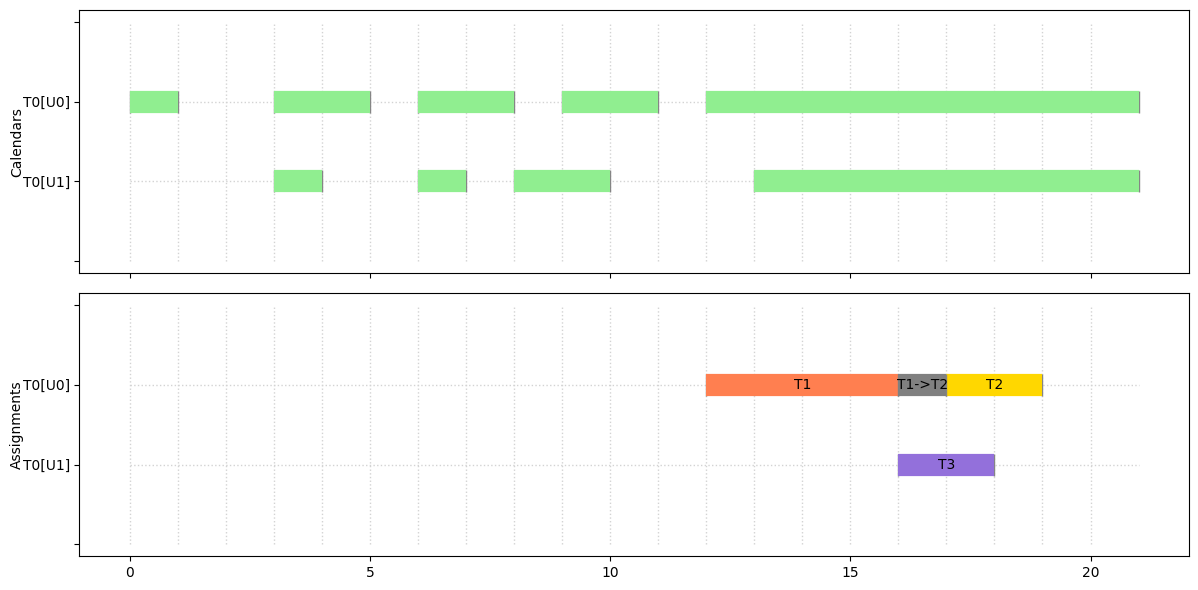

<Figure size 1200x600 with 0 Axes>

In [8]:
# Extract and display the schedule
v1_schedule = []
for tid, _, _ in inst['tasks']:
    tv = sol.get_var_solution(T[tid])
    resources = sorted(
        u for (ti, u), iv in O.items()
        if ti == tid and (sv := sol.get_var_solution(iv)) and sv.is_present()
    )
    v1_schedule.append({
        'id': tid, 'start': int(tv.get_start()), 'end': int(tv.get_end()),
        'resources': resources,
    })
    print(f'  T{tid}: [{tv.get_start()},{tv.get_end()}) resources={resources}')

visualize(inst, v1_schedule, title='V1 — No Migration | No Interruption (CPO)')


### OptalCP implementation

Mirrors `rcpsptt_cal/cal/models/optalcp.py`.

OptalCP has no built-in `alternative(cardinality=q)`, so the cardinality requirement is encoded as `sum(presence) == q` plus explicit `start_at_start` / `end_at_end` synchronisation with the master interval.

In [9]:
import optalcp as cp

mdl_o = cp.Model(name='rcpsptt_cal_v1_optalcp')
avail_o = {uid: mdl_o.step_function([[t, v] for t, v in steps])
           for uid, steps in inst['units']}

To = {tid: mdl_o.interval_var(length=size, name=f'T{tid}')
      for tid, size, _ in inst['tasks']}
Oo = {(tid, u): mdl_o.interval_var(length=size, optional=True, name=f'T{tid}_U{u}')
      for tid, size, _ in inst['tasks'] for u in CAND[tid]}

mdl_o.minimize(mdl_o.max([To[i].end() for i in To]))
mdl_o.enforce([To[i].end_before_start(To[j]) for i, j in E])

for tid, _, reqs in inst['tasks']:
    for type_id, qty in reqs:
        if qty > 0 and (units := type_map.get(type_id, ())):
            ci = [Oo[(tid, u)] for u in units]
            mdl_o.enforce(mdl_o.sum([iv.presence() for iv in ci]) == qty)
            mdl_o.enforce([To[tid].start_at_start(iv) for iv in ci])
            mdl_o.enforce([To[tid].end_at_end(iv) for iv in ci])

for (_, u), iv in Oo.items():
    if u in avail_o:
        iv.forbid_extent(avail_o[u])

for uid, _ in inst['units']:
    items = [tid for tid, _, _ in inst['tasks'] if (tid, uid) in Oo]
    if not items:
        continue
    ivs = [Oo[(tid, uid)] for tid in items]
    trans = transition_matrix_for_unit(uid, items, unit_to_type, transfer_map)
    seq = mdl_o.sequence_var(ivs, types=list(range(len(items))))
    mdl_o.enforce(seq.no_overlap(trans))

res_o = mdl_o.solve(parameters=cp.Parameters(timeLimit=30, nbWorkers=8, logLevel=0))
print('Makespan:', res_o.objective, '| bound:', res_o.objective_bound)


Makespan: 19.0 | bound: 19.0


  T0: [0,0) resources=[]
  T1: [12,16) resources=[0]
  T2: [16,18) resources=[1]
  T3: [17,19) resources=[0]
  T4: [19,19) resources=[]


<Figure size 1200x600 with 0 Axes>

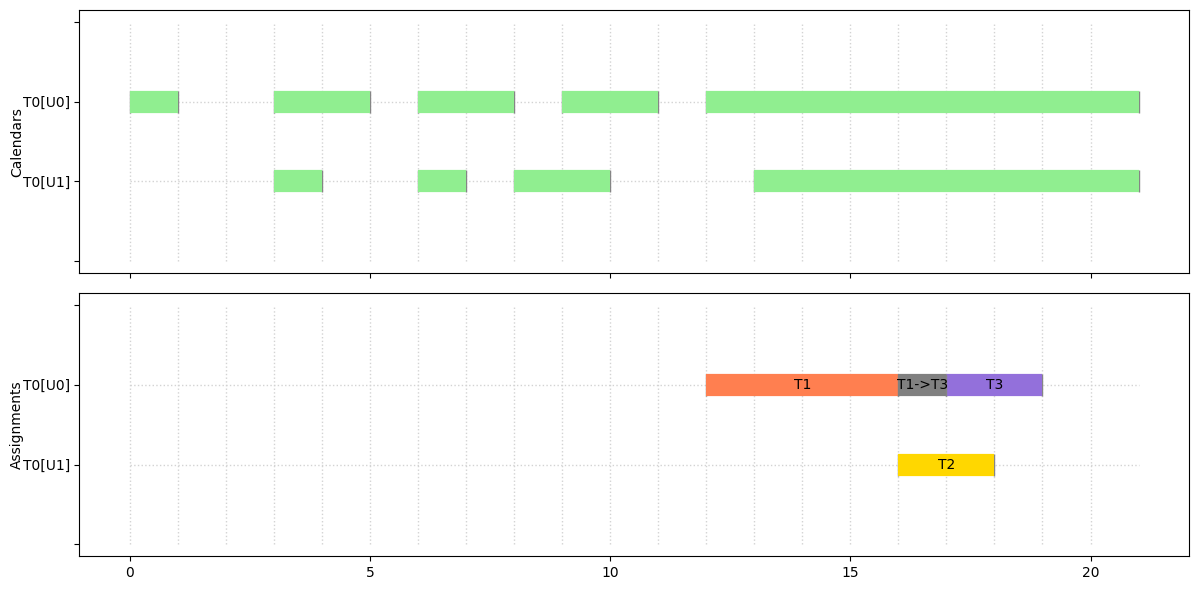

<Figure size 1200x600 with 0 Axes>

In [10]:
v1o_schedule = []
if res_o.solution is not None:
    sol_o = res_o.solution
    for tid, _, _ in inst['tasks']:
        s = int(sol_o.get_start(To[tid]))
        e = int(sol_o.get_end(To[tid]))
        resources = sorted(u for (ti, u), iv in Oo.items()
                           if ti == tid and sol_o.is_present(iv))
        v1o_schedule.append({'id': tid, 'start': s, 'end': e, 'resources': resources})
        print(f'  T{tid}: [{s},{e}) resources={resources}')

visualize(inst, v1o_schedule, title='V1 — No Migration | No Interruption (OptalCP)')


## Variant 2 — Migration | No Interruption
(`RCPSP-TT|cal,migration,nointerruption|Cmax`)

The task runs **continuously** (span = size), but the *set* of units serving it may change over time. At every instant exactly $q_{i,k}$ units of each type $k$ are active. Each unit contributes one contiguous block $O_{i,u} \subseteq T_i$; when it later serves another activity, the transfer time applies.

$$
\begin{aligned}
\min\ & \operatorname{end}(T_{n-1}) && \text{(1)} \\[1mm]
& \operatorname{endBeforeStart}(T_i, T_j) && \forall (i,j)\in\mathcal{E}^\star && \text{(2)} \\[1mm]
& \operatorname{alwaysIn}\!\Big(\textstyle\sum_{u\in\mathcal{U}_k}\operatorname{pulse}(O_{i,u},1),\ T_i,\ q_{i,k},\ q_{i,k}\Big) && \forall i,k && \text{(3)} \\[1mm]
& \textstyle\sum_{u}\operatorname{sizeOf}(O_{i,u}) = q_{i,k}\,p_i && \forall i,k && \text{(4)} \\[1mm]
& O_{i,u}\subseteq T_i && \forall i,u && \text{(5)} \\[1mm]
& \operatorname{forbidExtent}(O_{i,u},\overline{\mathcal{F}_u}) && \forall i,u && \text{(6)} \\[1mm]
& \operatorname{noOverlap}(\operatorname{seq}_u,\,(\Delta_{ij,\kappa(u)})) && \forall u && \text{(7)}
\end{aligned}
$$

In OptalCP `alwaysIn` is unavailable; (3)+(4) become `sum(pulse)≤q` plus the same total-length equation (pointwise ≤ q with area $q p_i$ forces = q).

### IBM CPO implementation

Mirrors `rcpsptt_cal/cal_migration_nointerruption/models/cpo.py`.

In [11]:
from docplex.cp.model import always_in, pulse, size_of, start_of

mdl2 = CpoModel(name='rcpsptt_cal_v2_cpo')

T2 = {tid: interval_var(size=size, name=f'T{tid}')
      for tid, size, _ in inst['tasks']}
O2 = {(tid, u): interval_var(optional=True, name=f'T{tid}_U{u}')
      for tid, _, _ in inst['tasks'] for u in CAND[tid]}

mdl2.add(minimize(mdl2.max([end_of(T2[i]) for i in T2])))
mdl2.add([end_before_start(T2[i], T2[j]) for i, j in E])

for tid, size, reqs in inst['tasks']:
    for type_id, qty in reqs:
        if qty <= 0:
            continue
        units = type_map.get(type_id, ())
        # (3) exactly qty units active at every instant of T_i
        mdl2.add(always_in(sum(pulse(O2[(tid, u)], 1) for u in units),
                           T2[tid], qty, qty))
        # (4) total coverage == qty * size
        mdl2.add(sum(size_of(O2[(tid, u)], 0) for u in units) == qty * size)
        for u in units:
            # (5) containment: absent start_of -> horizon, absent end_of -> 0
            mdl2.add(start_of(O2[(tid, u)], HORIZON) >= start_of(T2[tid]))
            mdl2.add(end_of(O2[(tid, u)], 0) <= end_of(T2[tid]))

# (6) calendar compliance
for (_, u), iv in O2.items():
    if u in avail:
        mdl2.add(forbid_extent(iv, avail[u]))

# (7) per-unit no-overlap with transfer-time matrix
for uid, _ in inst['units']:
    items = [tid for tid, _, _ in inst['tasks'] if (tid, uid) in O2]
    if not items:
        continue
    ivs = [O2[(tid, uid)] for tid in items]
    tm_vals = transition_matrix_for_unit(uid, items, unit_to_type, transfer_map)
    tm = CpoTransitionMatrix(size=len(items))
    for a in range(len(items)):
        for b in range(len(items)):
            tm.set_value(a, b, tm_vals[a][b])
    seq = sequence_var([O2[(tid, uid)] for tid in items],
                       types=list(range(len(items))), name=f'seq_U{uid}')
    mdl2.add(no_overlap(seq, tm))

sol2 = mdl2.solve(TimeLimit=30, LogVerbosity='Quiet')
print('Status:', sol2.get_solve_status(), '| Makespan:', sol2.get_objective_values()[0])


Status: Optimal | Makespan: 15


  T0: [0,0) segs=[]
  T1: [6,10) segs=[(6, 8, [0]), (8, 10, [1])]
  T2: [12,14) segs=[(12, 14, [0])]
  T3: [13,15) segs=[(13, 15, [1])]
  T4: [15,15) segs=[]


<Figure size 1200x600 with 0 Axes>

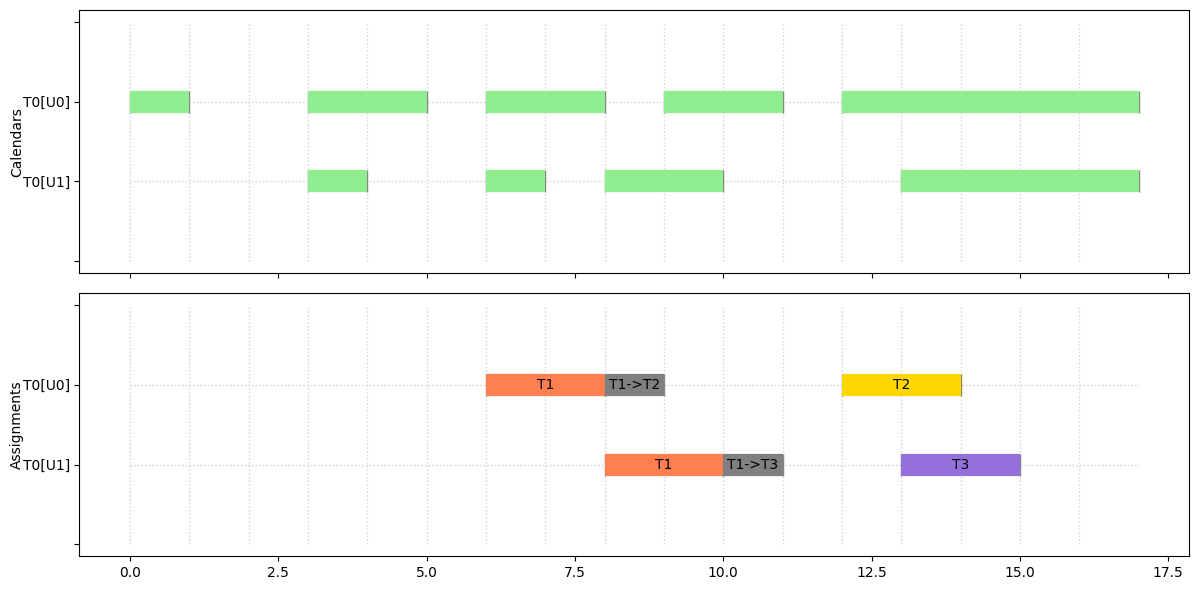

<Figure size 1200x600 with 0 Axes>

In [12]:
v2_schedule = []
for tid, _, _ in inst['tasks']:
    tv = sol2.get_var_solution(T2[tid])
    blocks = []
    for u in CAND[tid]:
        ov = sol2.get_var_solution(O2[(tid, u)])
        if ov.is_present() and ov.get_end() > ov.get_start():
            blocks.append((u, int(ov.get_start()), int(ov.get_end())))
    segs = [{'start': s, 'end': e, 'resources': list(us)}
            for s, e, us in blocks_to_segments(blocks)]
    v2_schedule.append({
        'id': tid, 'start': int(tv.get_start()), 'end': int(tv.get_end()),
        'segments': segs or None,
    })
    print(f'  T{tid}: [{tv.get_start()},{tv.get_end()}) segs={[(s["start"],s["end"],s["resources"]) for s in segs]}')

visualize(inst, v2_schedule, title='V2 — Migration | No Interruption (CPO)')


### OptalCP implementation

Mirrors `rcpsptt_cal/cal_migration_nointerruption/models/optalcp.py`.

In [13]:
mdl2o = cp.Model(name='rcpsptt_cal_v2_optalcp')
avail2o = {uid: mdl2o.step_function([[t, v] for t, v in steps])
           for uid, steps in inst['units']}

T2o = {tid: mdl2o.interval_var(length=size, name=f'T{tid}')
       for tid, size, _ in inst['tasks']}
O2o = {(tid, u): mdl2o.interval_var(optional=True, name=f'T{tid}_U{u}')
       for tid, _, _ in inst['tasks'] for u in CAND[tid]}

mdl2o.minimize(mdl2o.max([T2o[i].end() for i in T2o]))
mdl2o.enforce([T2o[i].end_before_start(T2o[j]) for i, j in E])

for tid, size, reqs in inst['tasks']:
    for type_id, qty in reqs:
        if qty <= 0:
            continue
        units = type_map.get(type_id, ())
        # OptalCP has no always_in: encode as pulse <=q plus total length
        mdl2o.enforce(mdl2o.sum([mdl2o.pulse(O2o[(tid, u)], 1)
                                 for u in units]) <= qty)
        mdl2o.enforce(mdl2o.sum([O2o[(tid, u)].length().guard(0)
                                  for u in units]) == qty * size)
        for u in units:
            mdl2o.enforce(T2o[tid].start_before_start(O2o[(tid, u)]))
            mdl2o.enforce(O2o[(tid, u)].end_before_end(T2o[tid]))

for (_, u), iv in O2o.items():
    if u in avail2o:
        iv.forbid_extent(avail2o[u])

for uid, _ in inst['units']:
    items = [tid for tid, _, _ in inst['tasks'] if (tid, uid) in O2o]
    if not items:
        continue
    ivs = [O2o[(tid, uid)] for tid in items]
    trans = transition_matrix_for_unit(uid, items, unit_to_type, transfer_map)
    seq = mdl2o.sequence_var(ivs, types=list(range(len(items))))
    mdl2o.enforce(seq.no_overlap(trans))

res2o = mdl2o.solve(parameters=cp.Parameters(timeLimit=30, nbWorkers=8, logLevel=0))
print('Makespan:', res2o.objective, '| bound:', res2o.objective_bound)


Makespan: 15.0 | bound: 15.0


  T0: [5,5) blocks=[]
  T1: [6,10) blocks=[(0, 6, 8), (1, 8, 10)]
  T2: [13,15) blocks=[(1, 13, 15)]
  T3: [12,14) blocks=[(0, 12, 14)]
  T4: [15,15) blocks=[]


<Figure size 1200x600 with 0 Axes>

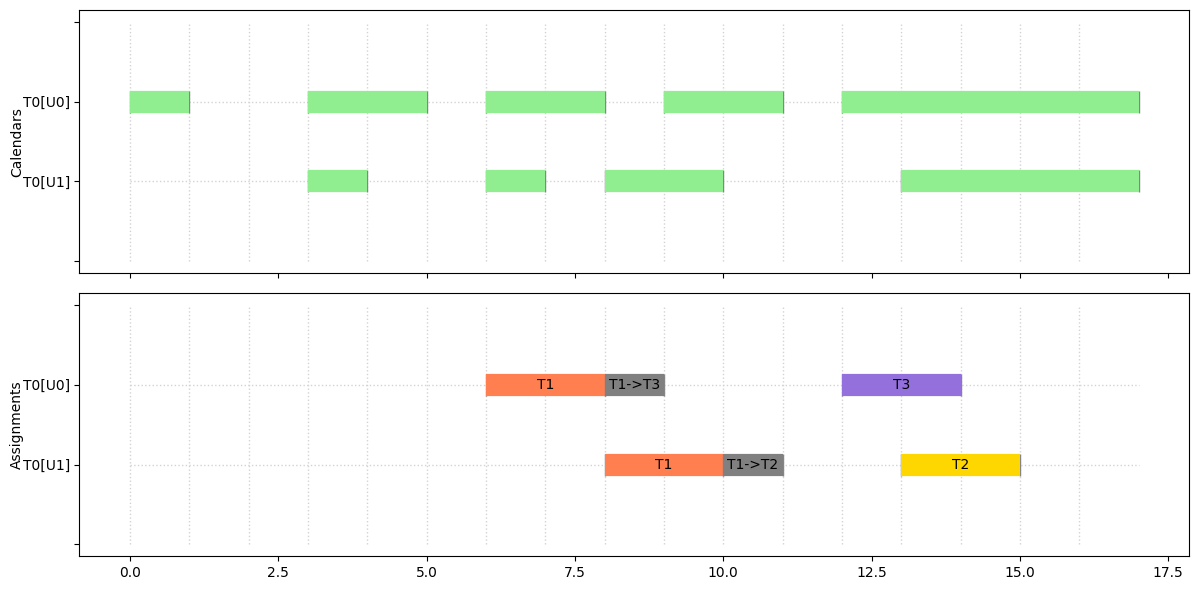

<Figure size 1200x600 with 0 Axes>

In [14]:
v2o_schedule = []
if res2o.solution is not None:
    sol2o = res2o.solution
    for tid, _, _ in inst['tasks']:
        s = int(sol2o.get_start(T2o[tid]))
        e = int(sol2o.get_end(T2o[tid]))
        blocks = []
        for u in CAND[tid]:
            if sol2o.is_present(O2o[(tid, u)]):
                bs = int(sol2o.get_start(O2o[(tid, u)]))
                be = int(sol2o.get_end(O2o[(tid, u)]))
                if be > bs:
                    blocks.append((u, bs, be))
        segs = [{'start': ss, 'end': ee, 'resources': list(us)}
                for ss, ee, us in blocks_to_segments(blocks)]
        v2o_schedule.append({'id': tid, 'start': s, 'end': e,
                             'segments': segs or None})
        print(f'  T{tid}: [{s},{e}) blocks={blocks}')

visualize(inst, v2o_schedule, title='V2 — Migration | No Interruption (OptalCP)')


## Variant 4 — No Migration | Blocked Interruption
(`RCPSP-TT|cal,nomigration,blockedinterruption|Cmax`)

The task keeps **one fixed unit set** (a *mode*) for its entire span, but may pause when any assigned unit is unavailable — and the units stay *blocked* (reserved) through the pause. Work accrues only when all mode units are simultaneously available (*joint intensity*). The span can therefore be larger than the processing time.

$$
\begin{aligned}
\min\ & \operatorname{end}(T_{n-1}) && \text{(1)} \\[1mm]
& \operatorname{endBeforeStart}(T_i, T_j) && \text{(2)} \\[1mm]
& \operatorname{alternative}(T_i,\,[O_{i,m}]_m) && \forall i && \text{(3)} \\[1mm]
& O_{i,m}\text{ has intensity }G_{i,m},\text{ size }p_i && && \text{(4)} \\[1mm]
& \operatorname{forbidStart}(O_{i,m},\, G_{i,m}) && && \text{(5)} \\[1mm]
& \operatorname{noOverlap}(\operatorname{seq}_u,\,(\Delta_{ij,\kappa(u)})) && \forall u && \text{(6)}
\end{aligned}
$$

Here $G_{i,m}$ is a step function that equals 100 (CPO) / 1 (OptalCP) when *all* units of mode $m$ are available and 0 otherwise. CPO uses `interval_var(size=p, intensity=G)` which accumulates $p$ units of full-intensity work; OptalCP uses `integral(G, O) == p` instead.

### IBM CPO implementation

Mirrors `rcpsptt_cal/cal_nomigration_blockedinterruption/models/cpo.py`.

In [15]:
from docplex.cp.model import forbid_start

task_modes = build_modes(inst['tasks'], type_map)

# joint intensity per (task, mode): 100 when ALL mode units available
G = {
    (tid, m): build_step_fn(joint_intensity_steps(task_modes[tid][m], res_map, 100))
    for tid, _, _ in inst['tasks']
    for m in range(len(task_modes[tid]))
}

mdl4 = CpoModel(name='rcpsptt_cal_v4_cpo')

T4 = {tid: interval_var(name=f'T{tid}') for tid, _, _ in inst['tasks']}
O4 = {
    (tid, m): interval_var(
        size=SIZE[tid], intensity=G[(tid, m)], optional=True, name=f'T{tid}_M{m}'
    )
    for tid, _, _ in inst['tasks']
    for m in range(len(task_modes[tid]))
}

mdl4.add(minimize(mdl4.max([end_of(T4[i]) for i in T4])))
mdl4.add([end_before_start(T4[i], T4[j]) for i, j in E])

# (3) alternative over modes
for tid, _, _ in inst['tasks']:
    mdl4.add(alternative(T4[tid], [O4[(tid, m)]
                                    for m in range(len(task_modes[tid]))]))
# (5) forbid start while any mode unit is unavailable
for (tid, m), iv in O4.items():
    mdl4.add(forbid_start(iv, G[(tid, m)]))

# (6) per-unit no-overlap with transition matrix (over unique task IDs)
for uid, _ in inst['units']:
    items = [(tid, m) for (tid, m) in O4 if uid in task_modes[tid][m]]
    if not items:
        continue
    ivs = [O4[(tid, m)] for tid, m in items]
    task_ids = [tid for tid, _ in items]
    uniq = sorted(set(task_ids))
    idx = {t: n for n, t in enumerate(uniq)}
    tm_vals = transition_matrix_for_unit(uid, uniq, unit_to_type, transfer_map)
    tm = CpoTransitionMatrix(size=len(uniq))
    for a in range(len(uniq)):
        for b in range(len(uniq)):
            tm.set_value(a, b, tm_vals[a][b])
    seq = sequence_var(ivs, types=[idx[t] for t in task_ids], name=f'seq_U{uid}')
    mdl4.add(no_overlap(seq, tm))

sol4 = mdl4.solve(TimeLimit=30, LogVerbosity='Quiet')
print('Status:', sol4.get_solve_status(), '| Makespan:', sol4.get_objective_values()[0])


Status: Optimal | Makespan: 11


  T0: [0,0) resources=[]
  T1: [0,7) resources=[0]
  T2: [9,11) resources=[0]
  T3: [8,10) resources=[1]
  T4: [11,11) resources=[]


<Figure size 1200x600 with 0 Axes>

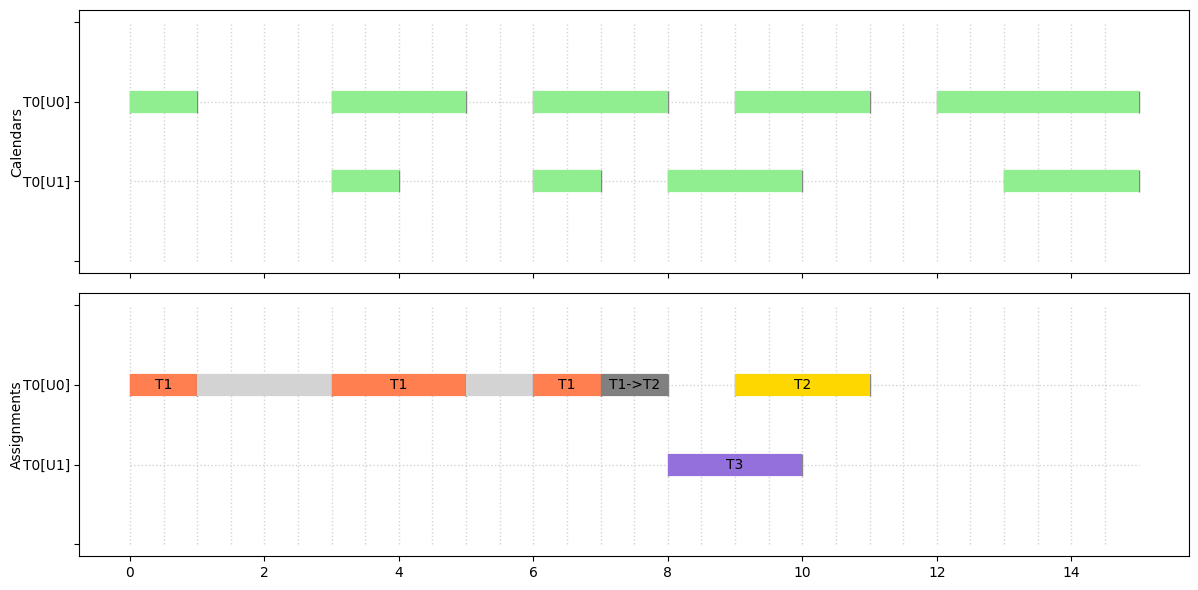

<Figure size 1200x600 with 0 Axes>

In [16]:
v4_schedule = []
for tid, _, _ in inst['tasks']:
    tv = sol4.get_var_solution(T4[tid])
    chosen = next(
        (task_modes[tid][m] for m in range(len(task_modes[tid]))
         if sol4.get_var_solution(O4[(tid, m)]).is_present()),
        (),
    )
    v4_schedule.append({
        'id': tid, 'start': int(tv.get_start()), 'end': int(tv.get_end()),
        'resources': sorted(chosen),
    })
    print(f'  T{tid}: [{tv.get_start()},{tv.get_end()}) resources={sorted(chosen)}')

visualize(inst, v4_schedule, title='V4 — No Migration | Blocked Interruption (CPO)')


### OptalCP implementation

Mirrors `rcpsptt_cal/cal_nomigration_blockedinterruption/models/optalcp.py`.

OptalCP cannot set per-interval intensity, so the work content is encoded as `integral(G, O) == size`; pauses via `forbid_start`.

In [17]:
mdl4o = cp.Model(name='rcpsptt_cal_v4_optalcp')

Go = {
    (tid, m): mdl4o.step_function(joint_intensity_steps(task_modes[tid][m], res_map, 1))
    for tid, _, _ in inst['tasks']
    for m in range(len(task_modes[tid]))
}

T4o = {tid: mdl4o.interval_var(name=f'T{tid}') for tid, _, _ in inst['tasks']}
O4o = {(tid, m): mdl4o.interval_var(optional=True, name=f'T{tid}_M{m}')
       for tid, _, _ in inst['tasks'] for m in range(len(task_modes[tid]))}

mdl4o.minimize(mdl4o.max([T4o[i].end() for i in T4o]))
mdl4o.enforce([T4o[i].end_before_start(T4o[j]) for i, j in E])

for tid, _, _ in inst['tasks']:
    mdl4o.enforce(mdl4o.alternative(T4o[tid],
                  [O4o[(tid, m)] for m in range(len(task_modes[tid]))]))

for tid, size, _ in inst['tasks']:
    if size <= 0:
        continue
    for m in range(len(task_modes[tid])):
        mdl4o.enforce(mdl4o.integral(Go[(tid, m)], O4o[(tid, m)]).guard(size) == size)

for (tid, m), iv in O4o.items():
    if task_modes[tid][m]:
        iv.forbid_start(Go[(tid, m)])

for uid, _ in inst['units']:
    items = [(tid, m) for (tid, m) in O4o if uid in task_modes[tid][m]]
    if not items:
        continue
    ivs = [O4o[(tid, m)] for tid, m in items]
    task_ids = [tid for tid, _ in items]
    uniq = sorted(set(task_ids))
    idx = {t: n for n, t in enumerate(uniq)}
    trans = transition_matrix_for_unit(uid, uniq, unit_to_type, transfer_map)
    seq = mdl4o.sequence_var(ivs, types=[idx[t] for t in task_ids])
    mdl4o.enforce(seq.no_overlap(trans))

res4o = mdl4o.solve(parameters=cp.Parameters(timeLimit=30, nbWorkers=8, logLevel=0))
print('Makespan:', res4o.objective, '| bound:', res4o.objective_bound)


Makespan: 11.0 | bound: 11.0


  T0: [0,0) resources=[]
  T1: [0,7) resources=[0]
  T2: [8,11) resources=[1]
  T3: [9,11) resources=[0]
  T4: [11,11) resources=[]


<Figure size 1200x600 with 0 Axes>

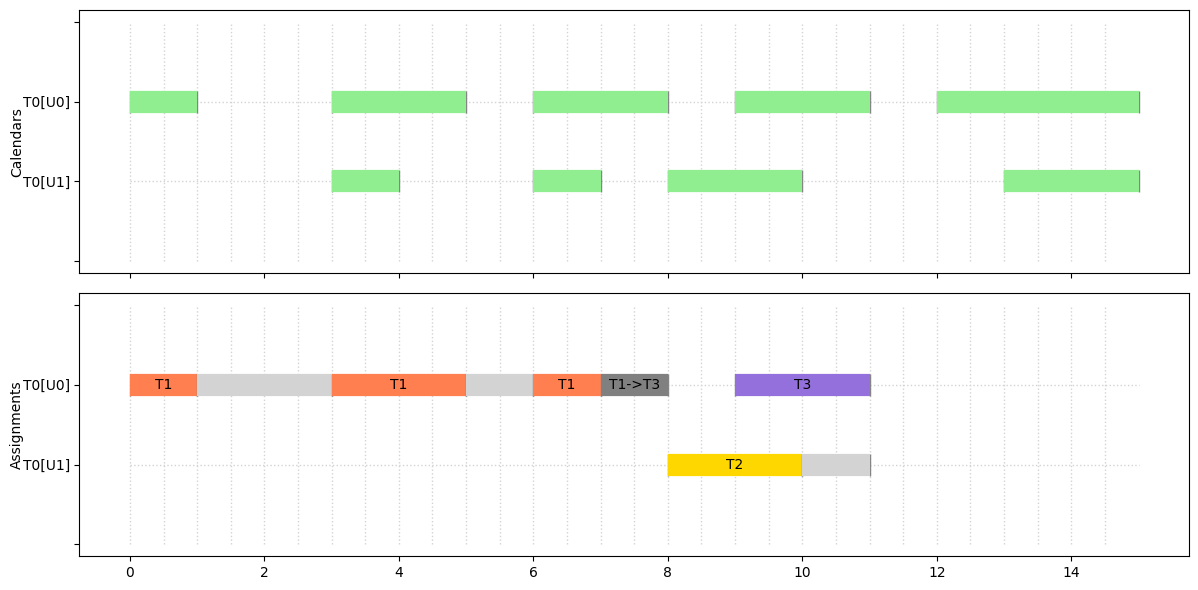

<Figure size 1200x600 with 0 Axes>

In [18]:
v4o_schedule = []
if res4o.solution is not None:
    sol4o = res4o.solution
    for tid, _, _ in inst['tasks']:
        s = int(sol4o.get_start(T4o[tid]))
        e = int(sol4o.get_end(T4o[tid]))
        chosen = next(
            (task_modes[tid][m] for m in range(len(task_modes[tid]))
             if sol4o.is_present(O4o[(tid, m)])),
            (),
        )
        v4o_schedule.append({'id': tid, 'start': s, 'end': e,
                             'resources': sorted(chosen)})
        print(f'  T{tid}: [{s},{e}) resources={sorted(chosen)}')

visualize(inst, v4o_schedule, title='V4 — No Migration | Blocked Interruption (OptalCP)')


## Variant 3 — Migration | Interruption
(`RCPSP-TT|cal,migration,interruption|Cmax`)

The most general variant: the task may be **paused** *and* change its unit set across pieces. It is split into up to $W$ preemptive segments; each present segment selects exactly $q_{i,k}$ units of each type (per-segment cardinality). Units keep identity; transfer times apply via the per-unit transition matrix.

$$
\begin{aligned}
\min\ & \operatorname{end}(T_{n-1}) && \text{(1)} \\[1mm]
& \operatorname{endBeforeStart}(T_i, T_j) && \text{(2)} \\[1mm]
& \operatorname{span}(T_i,\,[S_{i,w}]_w) && \forall i && \text{(3)} \\[1mm]
& \textstyle\sum_w \operatorname{lengthOf}(S_{i,w}) = p_i && \forall i && \text{(4)} \\[1mm]
& \operatorname{alternative}(S_{i,w},\,[O_{i,w,u}]_u,\,q_{i,k}) && \forall i,w,k && \text{(5)} \\[1mm]
& \operatorname{forbidExtent}(O_{i,w,u},\overline{\mathcal{F}_u}) && && \text{(6)} \\[1mm]
& \operatorname{noOverlap}(\operatorname{seq}_u,\,(\Delta_{ij,\kappa(u)})) && \forall u && \text{(7)}
\end{aligned}
$$

The number of segments is fixed to `MAX_SEGS = 4` (a conservative upper bound). Segments are lexicographically ordered and presence is monotonically non-increasing: if segment $w$ is absent, all later segments must be absent too.

### IBM CPO implementation

Mirrors `rcpsptt_cal/cal_migration_interruption/models/cpo.py`.

In [19]:
from docplex.cp.model import length_of, presence_of, span

MAX_SEGS = 4

mdl3 = CpoModel(name='rcpsptt_cal_v3_cpo')

T3 = {tid: interval_var(name=f'T{tid}') for tid, _, _ in inst['tasks']}
S3 = {(tid, w): interval_var(optional=True, name=f'T{tid}_seg{w}')
      for tid, _, _ in inst['tasks'] for w in range(MAX_SEGS)}
O3 = {(tid, w, u): interval_var(optional=True, name=f'T{tid}_seg{w}_U{u}')
      for tid, _, _ in inst['tasks']
      for w in range(MAX_SEGS)
      for u in CAND[tid]}

mdl3.add(minimize(mdl3.max([end_of(T3[i]) for i in T3])))
mdl3.add([end_before_start(T3[i], T3[j]) for i, j in E])

for tid, size, reqs in inst['tasks']:
    segs = [S3[(tid, w)] for w in range(MAX_SEGS)]
    # (3) span: T covers all segments
    mdl3.add(span(T3[tid], segs))
    # ordering and monotone presence
    for w in range(MAX_SEGS - 1):
        mdl3.add(end_before_start(S3[(tid, w)], S3[(tid, w + 1)]))
        mdl3.add(presence_of(S3[(tid, w + 1)]) <= presence_of(S3[(tid, w)]))
    # (4) total worked time == size
    mdl3.add(sum(length_of(S3[(tid, w)], 0) for w in range(MAX_SEGS)) == size)
    if size > 0:
        mdl3.add(presence_of(S3[(tid, 0)]) == 1)
    # (5) per-segment cardinality alternative
    for w in range(MAX_SEGS):
        for type_id, qty in reqs:
            if qty > 0 and (units := type_map.get(type_id, ())):
                mdl3.add(alternative(
                    S3[(tid, w)],
                    [O3[(tid, w, u)] for u in units],
                    cardinality=qty,
                ))

# (6) calendar compliance
for (_, _, u), iv in O3.items():
    if u in avail:
        mdl3.add(forbid_extent(iv, avail[u]))

# (7) per-unit no-overlap with transfer-time matrix (indexed by unique task IDs)
for uid, _ in inst['units']:
    items = [(tid, w) for (tid, w, uu) in O3 if uu == uid]
    if not items:
        continue
    ivs = [O3[(tid, w, uid)] for tid, w in items]
    task_ids = [tid for tid, _ in items]
    uniq = sorted(set(task_ids))
    idx = {t: n for n, t in enumerate(uniq)}
    tm_vals = transition_matrix_for_unit(uid, uniq, unit_to_type, transfer_map)
    tm = CpoTransitionMatrix(size=len(uniq))
    for a in range(len(uniq)):
        for b in range(len(uniq)):
            tm.set_value(a, b, tm_vals[a][b])
    seq = sequence_var(ivs, types=[idx[t] for t in task_ids], name=f'seq_U{uid}')
    mdl3.add(no_overlap(seq, tm))

sol3 = mdl3.solve(TimeLimit=30, LogVerbosity='Quiet')
print('Status:', sol3.get_solve_status(), '| Makespan:', sol3.get_objective_values()[0])


Status: Optimal | Makespan: 10


  T0: [0,0) segs=[]
  T1: [0,7) segs=[(0, 1, [0]), (3, 5, [0]), (6, 7, [1])]
  T2: [8,10) segs=[(8, 10, [1])]
  T3: [7,10) segs=[(7, 8, [0]), (9, 10, [0])]
  T4: [10,10) segs=[]


<Figure size 1200x600 with 0 Axes>

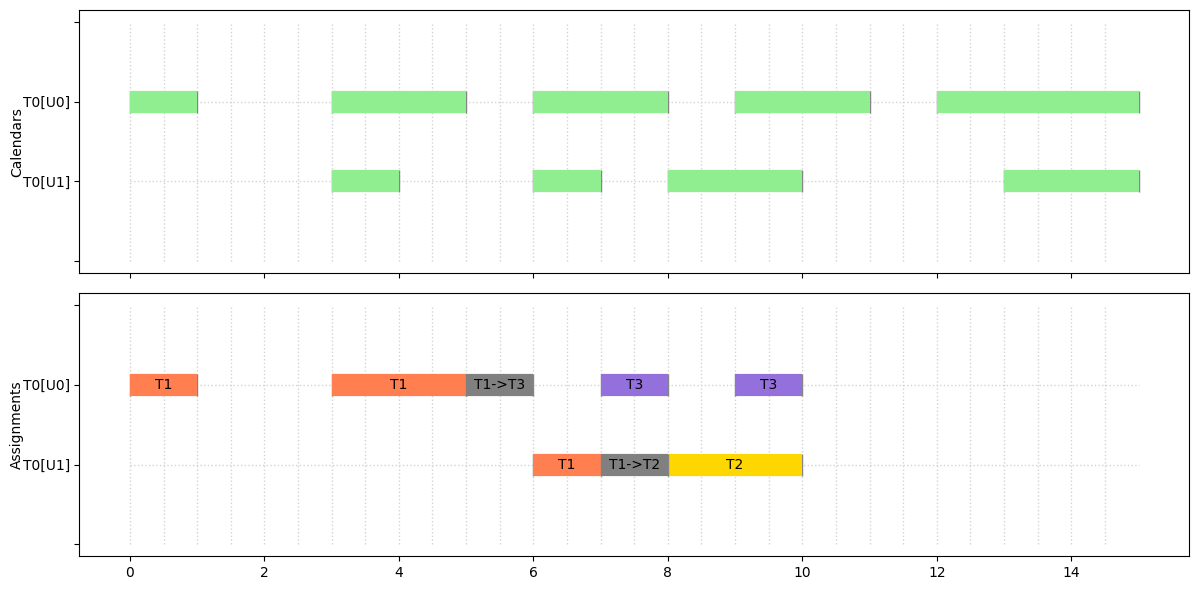

<Figure size 1200x600 with 0 Axes>

In [20]:
v3_schedule = []
for tid, _, _ in inst['tasks']:
    tv = sol3.get_var_solution(T3[tid])
    segs = []
    for w in range(MAX_SEGS):
        sv = sol3.get_var_solution(S3[(tid, w)])
        if sv.is_present() and sv.get_end() > sv.get_start():
            units = sorted(
                u for u in CAND[tid]
                if sol3.get_var_solution(O3[(tid, w, u)]).is_present()
            )
            segs.append({'start': int(sv.get_start()), 'end': int(sv.get_end()),
                         'resources': units})
    v3_schedule.append({
        'id': tid, 'start': int(tv.get_start()), 'end': int(tv.get_end()),
        'segments': segs or None,
    })
    print(f'  T{tid}: [{tv.get_start()},{tv.get_end()}) segs={[(s["start"],s["end"],s["resources"]) for s in segs]}')

visualize(inst, v3_schedule, title='V3 — Migration | Interruption (CPO)')


### OptalCP implementation

Mirrors `rcpsptt_cal/cal_migration_interruption/models/optalcp.py`.

Since OptalCP has no `span()` primitive, the span constraint is expressed as `T.start_before_start(S[0])` and `S[last].end_before_end(T)`. Per-segment cardinality uses `sum(presence) == qty * presence(S[w])`.

In [21]:
mdl3o = cp.Model(name='rcpsptt_cal_v3_optalcp')
avail3o = {uid: mdl3o.step_function([[t, v] for t, v in steps])
           for uid, steps in inst['units']}

T3o = {tid: mdl3o.interval_var(name=f'T{tid}') for tid, _, _ in inst['tasks']}
S3o = {(tid, w): mdl3o.interval_var(optional=True, name=f'T{tid}_seg{w}')
       for tid, _, _ in inst['tasks'] for w in range(MAX_SEGS)}
O3o = {(tid, w, u): mdl3o.interval_var(optional=True, name=f'T{tid}_seg{w}_U{u}')
       for tid, _, _ in inst['tasks']
       for w in range(MAX_SEGS)
       for u in CAND[tid]}

mdl3o.minimize(mdl3o.max([T3o[i].end() for i in T3o]))
mdl3o.enforce([T3o[i].end_before_start(T3o[j]) for i, j in E])

for tid, size, reqs in inst['tasks']:
    segs = [S3o[(tid, w)] for w in range(MAX_SEGS)]
    mdl3o.enforce(mdl3o.span(T3o[tid], segs))
    for w in range(MAX_SEGS - 1):
        mdl3o.enforce(S3o[(tid, w)].end_before_start(S3o[(tid, w + 1)]))
        mdl3o.enforce(S3o[(tid, w + 1)].presence() <= S3o[(tid, w)].presence())
    mdl3o.enforce(
        mdl3o.sum([S3o[(tid, w)].length().guard(0) for w in range(MAX_SEGS)]) == size
    )
    if size > 0:
        mdl3o.enforce(S3o[(tid, 0)].presence() == 1)
    for w in range(MAX_SEGS):
        for type_id, qty in reqs:
            if qty > 0 and (units := type_map.get(type_id, ())):
                ci = [O3o[(tid, w, u)] for u in units]
                mdl3o.enforce(
                    mdl3o.sum([iv.presence() for iv in ci])
                    == qty * S3o[(tid, w)].presence()
                )
                mdl3o.enforce([S3o[(tid, w)].start_at_start(iv) for iv in ci])
                mdl3o.enforce([S3o[(tid, w)].end_at_end(iv) for iv in ci])

for (_, _, u), iv in O3o.items():
    if u in avail3o:
        iv.forbid_extent(avail3o[u])

for uid, _ in inst['units']:
    items = [(tid, w) for (tid, w, uu) in O3o if uu == uid]
    if not items:
        continue
    ivs = [O3o[(tid, w, uid)] for tid, w in items]
    task_ids = [tid for tid, _ in items]
    uniq = sorted(set(task_ids))
    idx = {t: n for n, t in enumerate(uniq)}
    trans = transition_matrix_for_unit(uid, uniq, unit_to_type, transfer_map)
    seq = mdl3o.sequence_var(ivs, types=[idx[t] for t in task_ids])
    mdl3o.enforce(seq.no_overlap(trans))

res3o = mdl3o.solve(parameters=cp.Parameters(timeLimit=30, nbWorkers=8, logLevel=0))
print('Makespan:', res3o.objective, '| bound:', res3o.objective_bound)


Makespan: 10.0 | bound: 10.0


  T0: [0,0) segs=[]
  T1: [0,7) segs=[(0, 1, [0]), (3, 5, [0]), (6, 7, [1])]
  T2: [7,10) segs=[(7, 8, [0]), (9, 10, [0])]
  T3: [8,10) segs=[(8, 10, [1])]
  T4: [10,10) segs=[]


<Figure size 1200x600 with 0 Axes>

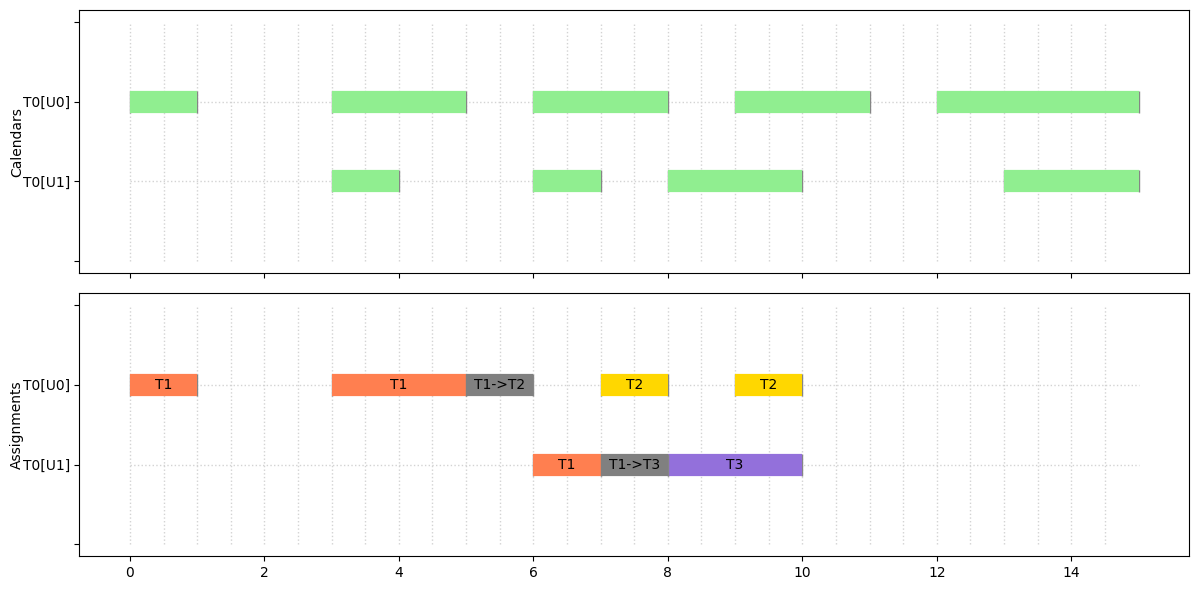

<Figure size 1200x600 with 0 Axes>

In [22]:
v3o_schedule = []
if res3o.solution is not None:
    sol3o = res3o.solution
    for tid, _, _ in inst['tasks']:
        s = int(sol3o.get_start(T3o[tid]))
        e = int(sol3o.get_end(T3o[tid]))
        segs = []
        for w in range(MAX_SEGS):
            if sol3o.is_present(S3o[(tid, w)]):
                ss = int(sol3o.get_start(S3o[(tid, w)]))
                ee = int(sol3o.get_end(S3o[(tid, w)]))
                if ee > ss:
                    units = sorted(u for u in CAND[tid]
                                   if sol3o.is_present(O3o[(tid, w, u)]))
                    segs.append({'start': ss, 'end': ee, 'resources': units})
        v3o_schedule.append({'id': tid, 'start': s, 'end': e,
                             'segments': segs or None})
        print(f'  T{tid}: [{s},{e}) segs={[(s_["start"],s_["end"],s_["resources"]) for s_ in segs]}')

visualize(inst, v3o_schedule, title='V3 — Migration | Interruption (OptalCP)')


## Comparing All Four Variants

The table below shows the expected makespan for each variant on `02.data`.
Each relaxation in the lattice V1 ≥ V2 ≥ V3 and V1 ≥ V4 ≥ V3 buys a strict improvement on this instance:

| Variant | Makespan | Key mechanism |
|---------|:---:|---|
| V1 no-mig / no-int | **19** | Fixed units, must be continuously available |
| V2 migration / no-int | **15** | Units swap mid-task across calendar windows |
| V4 no-mig / blocked-int | **11** | Task pauses through breaks, units stay blocked |
| V3 migration / int | **10** | Pause *and* swap units — most flexible |

On this instance the calendar effect dominates the transfer-time effect:
removing calendars drops the V1 makespan from 19 to 7; removing transfer
times alone drops it from 19 to 18.

In [23]:
# Collect results from all solved variants
results = {}

def extract_obj(sol_obj):
    """Get objective from either a CPO SolveResult or OptalCP result."""
    if hasattr(sol_obj, 'get_objective_values'):  # CPO
        vals = sol_obj.get_objective_values()
        return vals[0] if vals else None
    return getattr(sol_obj, 'objective', None)   # OptalCP

results['V1 (CPO)'] = extract_obj(sol)
results['V1 (OptalCP)'] = res_o.objective if res_o.solution else None
results['V2 (CPO)'] = extract_obj(sol2)
results['V2 (OptalCP)'] = res2o.objective if res2o.solution else None
results['V4 (CPO)'] = extract_obj(sol4)
results['V4 (OptalCP)'] = res4o.objective if res4o.solution else None
results['V3 (CPO)'] = extract_obj(sol3)
results['V3 (OptalCP)'] = res3o.objective if res3o.solution else None

print(f"{'Variant':<25} {'Makespan':>10}")
print('-' * 37)
for k, v in results.items():
    print(f"{k:<25} {str(v):>10}")


Variant                     Makespan
-------------------------------------
V1 (CPO)                          19
V1 (OptalCP)                    19.0
V2 (CPO)                          15
V2 (OptalCP)                    15.0
V4 (CPO)                          11
V4 (OptalCP)                    11.0
V3 (CPO)                          10
V3 (OptalCP)                    10.0


## Transfer Semantics — Gap, Atomic, Split

So far every variant treated the transfer time $\Delta_{i,j}$ as a **sequence-dependent
setup** on each unit's `noOverlap` (the transition matrix). That enforces only a
*minimum separation*: if unit $u$ does activity $i$ then activity $j$, at least
$\Delta_{i,j}$ time must elapse between them — **regardless of the calendar**. The
unit may well be "in transit" during an off-period. Call this the **gap** semantics.

But what *is* $\Delta$ physically? Two readings, two extra semantics:

| Semantic | Physical meaning | Calendar rule on the transfer |
|----------|------------------|-------------------------------|
| **gap** | a cooldown / mandatory delay (machine cools, paint dries) | none — may span off-time |
| **atomic** | an indivisible physical move that must happen in one go | the whole $\Delta$ fits **one** availability window |
| **split** | a physical move that can pause overnight and resume | accrues $\Delta$ of **available** time, pausing over breaks |

`gap` is the transition-matrix model from above. `atomic`/`split` need the transfer
to be a **first-class interval** that consumes calendar time, so the transition
matrix is no longer enough — we switch to an explicit per-unit **routing (flow)**.

### CP formulation of the routing (atomic / split)

For each unit $u$ we build a path through the operation intervals it performs.
Let $O$ be a unit's operation nodes (whole tasks for V1/V2, mode-intervals for V4,
segments for V3) and add dummy source $\sigma_u$ / sink $\tau_u$ nodes. For every
ordered, precedence-feasible pair $(a,b)$ introduce an **optional transfer interval**
$Z_{a,b,u}$.

$$
\begin{aligned}
\min \quad & \operatorname{end}(T_{n-1}) & & \text{(1)} \\[1mm]
\text{s.t.}\quad
& \operatorname{presenceOf}(Z_{a,b,u}) \Rightarrow \operatorname{presenceOf}(a)\wedge\operatorname{presenceOf}(b) & & \text{(2)} \\[1mm]
& \textstyle\sum_{a}\operatorname{presenceOf}(Z_{a,o,u}) = \operatorname{presenceOf}(o),\quad \sum_{b}\operatorname{presenceOf}(Z_{o,b,u}) = \operatorname{presenceOf}(o) & \forall o & \text{(3)} \\[1mm]
& \textstyle\sum_{b}\operatorname{presenceOf}(Z_{\sigma_u,b,u}) = 1,\quad \sum_{a}\operatorname{presenceOf}(Z_{a,\tau_u,u}) = 1 & & \text{(4)} \\[1mm]
& \operatorname{endBeforeStart}(a, Z_{a,b,u}),\quad \operatorname{endBeforeStart}(Z_{a,b,u}, b) & & \text{(5)} \\[1mm]
& \textbf{atomic:}\ \ \operatorname{lengthOf}(Z_{a,b,u}) = \Delta_{a,b},\ \ \operatorname{forbidExtent}(Z_{a,b,u}, \overline{\mathcal{F}_u}) & & \text{(6a)} \\[1mm]
& \textbf{split:}\ \ \textstyle\int_{Z_{a,b,u}} \mathcal{F}_u = \Delta_{a,b},\ \ \operatorname{forbidStart/End}(Z_{a,b,u}, \overline{\mathcal{F}_u}) & & \text{(6b)} \\[1mm]
& \operatorname{noOverlap}\big(\{O\}_u \cup \{Z_{a,b,u}\}\big) & & \text{(7)}
\end{aligned}
$$

- **(2)** a transfer exists only between two performed activities.
- **(3)+(4)** flow conservation — every performed node has exactly one incoming and one
  outgoing transfer; this is what **forces** a $\Delta$-transfer to actually occur
  between consecutive activities (the gap model gets this "for free" from the matrix).
- **(5)** the transfer sits between the two activities it links.
- **(6a) atomic** — a fixed-length $\Delta$ interval forbidden from overlapping any
  off-period ⇒ it lands inside one window. **(6b) split** — an elastic interval whose
  *available-time integral* equals $\Delta$ (CPO models this directly with
  `interval_var(size=Δ, intensity=F_u)`; OptalCP with `integral(F_u, Z) == Δ`),
  so it pauses over breaks.
- **(7)** a redundant `noOverlap` (we keep the transition matrix too) gives the solver
  the strong disjunctive propagation — the flow alone propagates poorly.

The operation nodes $O$ are exactly the per-variant intervals defined in the four
sections above; only the transfer block changes. Below, one generic builder per
engine covers all $4 \times 3$ combinations.

In [24]:
# ── Shared routing (flow) builders ──────────────────────────────────────
# unit_nodes: {unit_id: [(node_key, task_id, interval_var), ...]}

def _flow_cpo(mdl, unit_nodes, avail, transfer):
    from docplex.cp.model import (CpoTransitionMatrix, end_before_start,
        forbid_extent, interval_var, no_overlap, presence_of, sequence_var)
    e_set = set(transitive_closure(inst['precedences'], inst['n_tasks']))
    SRC, SINK = '__src__', '__sink__'
    meta = []
    for u, nodes in unit_nodes.items():
        if not nodes:
            continue
        keys = [k for k, _, _ in nodes]
        iv_of = {k: iv for k, _, iv in nodes}
        task_of = {k: t for k, t, _ in nodes}
        iv_of[SRC] = interval_var(size=0)
        iv_of[SINK] = interval_var(size=0)
        # redundant transition matrix on operation intervals (strong bound)
        op_tasks = [task_of[k] for k in keys]
        uniq = sorted(set(op_tasks)); idx = {t: n for n, t in enumerate(uniq)}
        tmv = transition_matrix_for_unit(u, uniq, unit_to_type, transfer_map)
        tm = CpoTransitionMatrix(size=len(uniq))
        for a in range(len(uniq)):
            for b in range(len(uniq)):
                tm.set_value(a, b, tmv[a][b])
        mdl.add(no_overlap(sequence_var([iv_of[k] for k in keys],
                                        types=[idx[t] for t in op_tasks]), tm))
        # arcs
        allk = [SRC] + keys + [SINK]; Z = {}
        for a in allk:
            for b in allk:
                if a == b or b == SRC or a == SINK:
                    continue
                if a == SRC or b == SINK:
                    d = 0
                else:
                    ta, tb = task_of[a], task_of[b]
                    if ta != tb and (tb, ta) in e_set:
                        continue
                    d = delta(u, ta, tb)
                if transfer == 'split' and d > 0 and u in avail:
                    z = interval_var(size=d, intensity=avail[u], optional=True)
                else:
                    z = interval_var(size=d, optional=True)
                    if transfer == 'atomic' and d > 0 and u in avail:
                        mdl.add(forbid_extent(z, avail[u]))
                Z[(a, b)] = z
                if a != SRC:
                    mdl.add(presence_of(z) <= presence_of(iv_of[a]))
                if b != SINK:
                    mdl.add(presence_of(z) <= presence_of(iv_of[b]))
                mdl.add(end_before_start(iv_of[a], z))
                mdl.add(end_before_start(z, iv_of[b]))
                if a != SRC and b != SINK and d > 0:
                    meta.append((u, z, task_of[a], task_of[b]))
        for k in keys:
            ins = [Z[(a, k)] for a in iv_of if (a, k) in Z]
            outs = [Z[(k, b)] for b in iv_of if (k, b) in Z]
            mdl.add(sum(presence_of(z) for z in ins) == presence_of(iv_of[k]))
            mdl.add(sum(presence_of(z) for z in outs) == presence_of(iv_of[k]))
        mdl.add(sum(presence_of(Z[(SRC, b)]) for b in iv_of if (SRC, b) in Z) == 1)
        mdl.add(sum(presence_of(Z[(a, SINK)]) for a in iv_of if (a, SINK) in Z) == 1)
        mdl.add(no_overlap(sequence_var([iv_of[k] for k in keys] + list(Z.values()))))

    def extract(sol):
        out = []
        for u, z, ta, tb in meta:
            zv = sol.get_var_solution(z)
            if zv and zv.is_present() and zv.get_end() > zv.get_start():
                out.append({'unit': u, 'start': int(zv.get_start()),
                            'end': int(zv.get_end()), 'from_task': ta, 'to_task': tb})
        return out
    return extract


def _flow_optal(mdl, unit_nodes, avail, transfer):
    e_set = set(transitive_closure(inst['precedences'], inst['n_tasks']))
    SRC, SINK = '__src__', '__sink__'
    avail01 = {uid: mdl.step_function([[t, 1 if v > 0 else 0] for t, v in steps])
               for uid, steps in inst['units']}
    meta = []
    for u, nodes in unit_nodes.items():
        if not nodes:
            continue
        keys = [k for k, _, _ in nodes]
        iv_of = {k: iv for k, _, iv in nodes}
        task_of = {k: t for k, t, _ in nodes}
        iv_of[SRC] = mdl.interval_var(length=0)
        iv_of[SINK] = mdl.interval_var(length=0)
        allk = [SRC] + keys + [SINK]; Z = {}
        for a in allk:
            for b in allk:
                if a == b or b == SRC or a == SINK:
                    continue
                if a == SRC or b == SINK:
                    d = 0
                else:
                    ta, tb = task_of[a], task_of[b]
                    if ta != tb and (tb, ta) in e_set:
                        continue
                    d = delta(u, ta, tb)
                if transfer == 'split' and d > 0 and u in avail01:
                    z = mdl.interval_var(optional=True)
                    mdl.enforce(mdl.integral(avail01[u], z).guard(d) == d)
                    z.forbid_start(avail01[u]); z.forbid_end(avail01[u])
                else:
                    z = mdl.interval_var(length=d, optional=True)
                    if transfer == 'atomic' and d > 0 and u in avail:
                        z.forbid_extent(avail[u])
                Z[(a, b)] = z
                if a != SRC:
                    mdl.enforce(z.presence() <= iv_of[a].presence())
                if b != SINK:
                    mdl.enforce(z.presence() <= iv_of[b].presence())
                mdl.enforce(iv_of[a].end_before_start(z))
                mdl.enforce(z.end_before_start(iv_of[b]))
                if a != SRC and b != SINK and d > 0:
                    meta.append((u, z, task_of[a], task_of[b]))
        for k in keys:
            ins = [Z[(a, k)] for a in iv_of if (a, k) in Z]
            outs = [Z[(k, b)] for b in iv_of if (k, b) in Z]
            mdl.enforce(mdl.sum([z.presence() for z in ins]) == iv_of[k].presence())
            mdl.enforce(mdl.sum([z.presence() for z in outs]) == iv_of[k].presence())
        mdl.enforce(mdl.sum([Z[(SRC, b)].presence() for b in iv_of if (SRC, b) in Z]) == 1)
        mdl.enforce(mdl.sum([Z[(a, SINK)].presence() for a in iv_of if (a, SINK) in Z]) == 1)
        mdl.enforce(mdl.no_overlap([iv_of[k] for k in keys] + list(Z.values())))

    def extract(res):
        out = []; sol = res.solution
        if sol is None:
            return out
        for u, z, ta, tb in meta:
            if sol.is_present(z) and sol.get_end(z) > sol.get_start(z):
                out.append({'unit': u, 'start': int(sol.get_start(z)),
                            'end': int(sol.get_end(z)), 'from_task': ta, 'to_task': tb})
        return out
    return extract


In [25]:
# ── Generic CPO solver: any variant x any transfer semantic ─────────────
def solve_cpo(variant, transfer, time_limit=10):
    from docplex.cp.model import (CpoModel, CpoTransitionMatrix, alternative,
        always_in, end_before_start, end_of, forbid_extent, forbid_start,
        interval_var, length_of, minimize, no_overlap, presence_of, pulse,
        sequence_var, size_of, span, start_of)
    tasks = inst['tasks']; H = HORIZON
    avail = {uid: build_step_fn(steps) for uid, steps in inst['units']}
    mdl = CpoModel()
    fixed = variant in ('V1', 'V2')
    T = {tid: (interval_var(size=size) if fixed else interval_var())
         for tid, size, _ in tasks}
    mdl.add(minimize(mdl.max([end_of(T[i]) for i in T])))
    mdl.add([end_before_start(T[i], T[j]) for i, j in E])
    kind = 'resources'

    if variant == 'V1':
        O = {(tid, u): interval_var(size=size, optional=True)
             for tid, size, _ in tasks for u in CAND[tid]}
        for tid, _, reqs in tasks:
            for ty, q in reqs:
                if q > 0 and (us := type_map.get(ty, ())):
                    mdl.add(alternative(T[tid], [O[(tid, u)] for u in us], cardinality=q))
        for (_, u), iv in O.items():
            if u in avail:
                mdl.add(forbid_extent(iv, avail[u]))
        unit_nodes = {uid: [(tid, tid, O[(tid, uid)]) for tid, _, _ in tasks if (tid, uid) in O]
                      for uid, _ in inst['units']}
    elif variant == 'V2':
        O = {(tid, u): interval_var(optional=True) for tid, _, _ in tasks for u in CAND[tid]}
        for tid, size, reqs in tasks:
            for ty, q in reqs:
                if q <= 0:
                    continue
                us = type_map.get(ty, ())
                mdl.add(always_in(sum(pulse(O[(tid, u)], 1) for u in us), T[tid], q, q))
                mdl.add(sum(size_of(O[(tid, u)], 0) for u in us) == q * size)
                for u in us:
                    mdl.add(start_of(O[(tid, u)], H) >= start_of(T[tid]))
                    mdl.add(end_of(O[(tid, u)], 0) <= end_of(T[tid]))
        for (_, u), iv in O.items():
            if u in avail:
                mdl.add(forbid_extent(iv, avail[u]))
        unit_nodes = {uid: [(tid, tid, O[(tid, uid)]) for tid, _, _ in tasks if (tid, uid) in O]
                      for uid, _ in inst['units']}
        kind = 'seg_v2'
    elif variant == 'V4':
        modes = build_modes(tasks, type_map)
        G = {(tid, m): build_step_fn(joint_intensity_steps(modes[tid][m], res_map, 100))
             for tid, _, _ in tasks for m in range(len(modes[tid]))}
        O = {(tid, m): interval_var(size=SIZE[tid], intensity=G[(tid, m)], optional=True)
             for tid, _, _ in tasks for m in range(len(modes[tid]))}
        for tid, _, _ in tasks:
            mdl.add(alternative(T[tid], [O[(tid, m)] for m in range(len(modes[tid]))]))
        for (tid, m), iv in O.items():
            mdl.add(forbid_start(iv, G[(tid, m)]))
        unit_nodes = {uid: [((tid, m), tid, O[(tid, m)]) for (tid, m) in O if uid in modes[tid][m]]
                      for uid, _ in inst['units']}
        kind = 'modes'
    else:  # V3
        MS = 4
        S = {(tid, w): interval_var(optional=True) for tid, _, _ in tasks for w in range(MS)}
        O = {(tid, w, u): interval_var(optional=True)
             for tid, _, _ in tasks for w in range(MS) for u in CAND[tid]}
        for tid, size, reqs in tasks:
            mdl.add(span(T[tid], [S[(tid, w)] for w in range(MS)]))
            for w in range(MS - 1):
                mdl.add(end_before_start(S[(tid, w)], S[(tid, w + 1)]))
                mdl.add(presence_of(S[(tid, w + 1)]) <= presence_of(S[(tid, w)]))
            mdl.add(sum(length_of(S[(tid, w)], 0) for w in range(MS)) == size)
            if size > 0:
                mdl.add(presence_of(S[(tid, 0)]) == 1)
            for w in range(MS):
                for ty, q in reqs:
                    if q > 0 and (us := type_map.get(ty, ())):
                        mdl.add(alternative(S[(tid, w)], [O[(tid, w, u)] for u in us], cardinality=q))
        for (_, _, u), iv in O.items():
            if u in avail:
                mdl.add(forbid_extent(iv, avail[u]))
        unit_nodes = {uid: [((tid, w), tid, O[(tid, w, uid)]) for (tid, w, uu) in O if uu == uid]
                      for uid, _ in inst['units']}
        kind = 'seg_v3'

    extract = None
    if transfer == 'gap':
        for uid, nodes in unit_nodes.items():
            if not nodes:
                continue
            ivs = [iv for _, _, iv in nodes]; task_ids = [t for _, t, _ in nodes]
            uniq = sorted(set(task_ids)); idx = {t: n for n, t in enumerate(uniq)}
            tmv = transition_matrix_for_unit(uid, uniq, unit_to_type, transfer_map)
            tm = CpoTransitionMatrix(size=len(uniq))
            for a in range(len(uniq)):
                for b in range(len(uniq)):
                    tm.set_value(a, b, tmv[a][b])
            mdl.add(no_overlap(sequence_var(ivs, types=[idx[t] for t in task_ids]), tm))
    else:
        extract = _flow_cpo(mdl, unit_nodes, avail, transfer)

    sol = mdl.solve(TimeLimit=time_limit, LogVerbosity='Quiet')
    st = str(sol.get_solve_status())
    if st not in ('Optimal', 'Feasible'):
        return {'makespan': None, 'status': st.lower(), 'schedule': [], 'transfers': None}
    mk = int(sol.get_objective_values()[0])
    transfers = extract(sol) if extract else None
    sched = []
    for tid, _, _ in tasks:
        tv = sol.get_var_solution(T[tid]); s, e = int(tv.get_start()), int(tv.get_end())
        if kind == 'resources':
            r = sorted(u for (ti, u), iv in O.items()
                       if ti == tid and (sv := sol.get_var_solution(iv)) and sv.is_present())
            sched.append({'id': tid, 'start': s, 'end': e, 'resources': r})
        elif kind == 'modes':
            ch = next((modes[tid][m] for m in range(len(modes[tid]))
                       if sol.get_var_solution(O[(tid, m)]).is_present()), ())
            sched.append({'id': tid, 'start': s, 'end': e, 'resources': sorted(ch)})
        elif kind == 'seg_v2':
            blocks = []
            for u in CAND[tid]:
                ov = sol.get_var_solution(O[(tid, u)])
                if ov.is_present() and ov.get_end() > ov.get_start():
                    blocks.append((u, int(ov.get_start()), int(ov.get_end())))
            segs = [{'start': ss, 'end': ee, 'resources': list(us)}
                    for ss, ee, us in blocks_to_segments(blocks)]
            sched.append({'id': tid, 'start': s, 'end': e, 'segments': segs or None})
        else:  # seg_v3
            segs = []
            for w in range(4):
                sv = sol.get_var_solution(S[(tid, w)])
                if sv.is_present() and sv.get_end() > sv.get_start():
                    us = sorted(u for u in CAND[tid]
                                if sol.get_var_solution(O[(tid, w, u)]).is_present())
                    segs.append({'start': int(sv.get_start()), 'end': int(sv.get_end()), 'resources': us})
            sched.append({'id': tid, 'start': s, 'end': e, 'segments': segs or None})
    return {'makespan': mk, 'status': st.lower(), 'schedule': sched, 'transfers': transfers}


In [26]:
# ── Generic OptalCP solver: any variant x any transfer semantic ─────────
def solve_optal(variant, transfer, time_limit=10):
    import optalcp as cp
    tasks = inst['tasks']
    mdl = cp.Model()
    avail = {uid: mdl.step_function([[t, v] for t, v in steps]) for uid, steps in inst['units']}
    fixed = variant in ('V1', 'V2')
    T = {tid: (mdl.interval_var(length=size) if fixed else mdl.interval_var())
         for tid, size, _ in tasks}
    mdl.minimize(mdl.max([T[i].end() for i in T]))
    mdl.enforce([T[i].end_before_start(T[j]) for i, j in E])
    kind = 'resources'

    if variant == 'V1':
        O = {(tid, u): mdl.interval_var(length=size, optional=True)
             for tid, size, _ in tasks for u in CAND[tid]}
        for tid, _, reqs in tasks:
            for ty, q in reqs:
                if q > 0 and (us := type_map.get(ty, ())):
                    ci = [O[(tid, u)] for u in us]
                    mdl.enforce(mdl.sum([iv.presence() for iv in ci]) == q)
                    mdl.enforce([T[tid].start_at_start(iv) for iv in ci])
                    mdl.enforce([T[tid].end_at_end(iv) for iv in ci])
        for (_, u), iv in O.items():
            if u in avail:
                iv.forbid_extent(avail[u])
        unit_nodes = {uid: [(tid, tid, O[(tid, uid)]) for tid, _, _ in tasks if (tid, uid) in O]
                      for uid, _ in inst['units']}
    elif variant == 'V2':
        O = {(tid, u): mdl.interval_var(optional=True) for tid, _, _ in tasks for u in CAND[tid]}
        for tid, size, reqs in tasks:
            for ty, q in reqs:
                if q <= 0:
                    continue
                us = type_map.get(ty, ())
                mdl.enforce(mdl.sum([mdl.pulse(O[(tid, u)], 1) for u in us]) <= q)
                mdl.enforce(mdl.sum([O[(tid, u)].length().guard(0) for u in us]) == q * size)
                for u in us:
                    mdl.enforce(T[tid].start_before_start(O[(tid, u)]))
                    mdl.enforce(O[(tid, u)].end_before_end(T[tid]))
        for (_, u), iv in O.items():
            if u in avail:
                iv.forbid_extent(avail[u])
        unit_nodes = {uid: [(tid, tid, O[(tid, uid)]) for tid, _, _ in tasks if (tid, uid) in O]
                      for uid, _ in inst['units']}
        kind = 'seg_v2'
    elif variant == 'V4':
        modes = build_modes(tasks, type_map)
        G = {(tid, m): mdl.step_function(joint_intensity_steps(modes[tid][m], res_map, 1))
             for tid, _, _ in tasks for m in range(len(modes[tid]))}
        O = {(tid, m): mdl.interval_var(optional=True)
             for tid, _, _ in tasks for m in range(len(modes[tid]))}
        for tid, _, _ in tasks:
            mdl.enforce(mdl.alternative(T[tid], [O[(tid, m)] for m in range(len(modes[tid]))]))
        for tid, size, _ in tasks:
            if size > 0:
                for m in range(len(modes[tid])):
                    mdl.enforce(mdl.integral(G[(tid, m)], O[(tid, m)]).guard(size) == size)
        for (tid, m), iv in O.items():
            if modes[tid][m]:
                iv.forbid_start(G[(tid, m)])
        unit_nodes = {uid: [((tid, m), tid, O[(tid, m)]) for (tid, m) in O if uid in modes[tid][m]]
                      for uid, _ in inst['units']}
        kind = 'modes'
    else:  # V3
        MS = 4
        S = {(tid, w): mdl.interval_var(optional=True) for tid, _, _ in tasks for w in range(MS)}
        O = {(tid, w, u): mdl.interval_var(optional=True)
             for tid, _, _ in tasks for w in range(MS) for u in CAND[tid]}
        for tid, size, reqs in tasks:
            mdl.enforce(mdl.span(T[tid], [S[(tid, w)] for w in range(MS)]))
            for w in range(MS - 1):
                mdl.enforce(S[(tid, w)].end_before_start(S[(tid, w + 1)]))
                mdl.enforce(S[(tid, w + 1)].presence() <= S[(tid, w)].presence())
            mdl.enforce(mdl.sum([S[(tid, w)].length().guard(0) for w in range(MS)]) == size)
            if size > 0:
                mdl.enforce(S[(tid, 0)].presence() == 1)
            for w in range(MS):
                for ty, q in reqs:
                    if q > 0 and (us := type_map.get(ty, ())):
                        ci = [O[(tid, w, u)] for u in us]
                        mdl.enforce(mdl.sum([iv.presence() for iv in ci]) == q * S[(tid, w)].presence())
                        mdl.enforce([S[(tid, w)].start_at_start(iv) for iv in ci])
                        mdl.enforce([S[(tid, w)].end_at_end(iv) for iv in ci])
        for (_, _, u), iv in O.items():
            if u in avail:
                iv.forbid_extent(avail[u])
        unit_nodes = {uid: [((tid, w), tid, O[(tid, w, uid)]) for (tid, w, uu) in O if uu == uid]
                      for uid, _ in inst['units']}
        kind = 'seg_v3'

    extract = None
    if transfer == 'gap':
        for uid, nodes in unit_nodes.items():
            if not nodes:
                continue
            ivs = [iv for _, _, iv in nodes]; task_ids = [t for _, t, _ in nodes]
            uniq = sorted(set(task_ids)); idx = {t: n for n, t in enumerate(uniq)}
            trans = transition_matrix_for_unit(uid, uniq, unit_to_type, transfer_map)
            seq = mdl.sequence_var(ivs, types=[idx[t] for t in task_ids])
            mdl.enforce(seq.no_overlap(trans))
    else:
        extract = _flow_optal(mdl, unit_nodes, avail, transfer)

    res = mdl.solve(parameters=cp.Parameters(timeLimit=time_limit, nbWorkers=8, logLevel=0))
    if res.solution is None:
        return {'makespan': None, 'status': 'unknown', 'schedule': [], 'transfers': None}
    sol = res.solution; mk = int(res.objective)
    transfers = extract(res) if extract else None
    sched = []
    for tid, _, _ in tasks:
        s, e = int(sol.get_start(T[tid])), int(sol.get_end(T[tid]))
        if kind == 'resources':
            r = sorted(u for (ti, u), iv in O.items() if ti == tid and sol.is_present(iv))
            sched.append({'id': tid, 'start': s, 'end': e, 'resources': r})
        elif kind == 'modes':
            ch = next((modes[tid][m] for m in range(len(modes[tid])) if sol.is_present(O[(tid, m)])), ())
            sched.append({'id': tid, 'start': s, 'end': e, 'resources': sorted(ch)})
        elif kind == 'seg_v2':
            blocks = []
            for u in CAND[tid]:
                if sol.is_present(O[(tid, u)]):
                    bs, be = int(sol.get_start(O[(tid, u)])), int(sol.get_end(O[(tid, u)]))
                    if be > bs:
                        blocks.append((u, bs, be))
            segs = [{'start': ss, 'end': ee, 'resources': list(us)}
                    for ss, ee, us in blocks_to_segments(blocks)]
            sched.append({'id': tid, 'start': s, 'end': e, 'segments': segs or None})
        else:
            segs = []
            for w in range(4):
                if sol.is_present(S[(tid, w)]):
                    ss, ee = int(sol.get_start(S[(tid, w)])), int(sol.get_end(S[(tid, w)]))
                    if ee > ss:
                        us = sorted(u for u in CAND[tid] if sol.is_present(O[(tid, w, u)]))
                        segs.append({'start': ss, 'end': ee, 'resources': us})
            sched.append({'id': tid, 'start': s, 'end': e, 'segments': segs or None})
    return {'makespan': mk, 'status': 'optimal' if mk == int(res.objective_bound) else 'feasible',
            'schedule': sched, 'transfers': transfers}


### The 4 × 3 grid

Solve every variant under every transfer semantic. OptalCP solves all twelve to
optimality quickly; CPO matches it except on the hardest cell (V3 = migration +
interruption) under `atomic`/`split`, where the routing model does not converge in
a short limit and only a feasible value is returned.

In [27]:
VARIANTS = ['V1', 'V2', 'V4', 'V3']
SEMANTICS = ['gap', 'atomic', 'split']
LABEL = {'V1': 'V1 no-mig/no-int', 'V2': 'V2 mig/no-int',
         'V4': 'V4 no-mig/blocked', 'V3': 'V3 mig/int'}

for engine, solve in (('OptalCP', solve_optal), ('CPO', solve_cpo)):
    print(f"\n=== {engine} ===   (makespan per variant x transfer semantic)")
    print(f"{'':20}" + "".join(f"{s:>8}" for s in SEMANTICS))
    for v in VARIANTS:
        row = [solve(v, s, time_limit=10)['makespan'] for s in SEMANTICS]
        print(f"{LABEL[v]:20}" + "".join(f"{str(x):>8}" for x in row))



=== OptalCP ===   (makespan per variant x transfer semantic)
                         gap  atomic   split
V1 no-mig/no-int          19      19      19
V2 mig/no-int             15      16      16
V4 no-mig/blocked         11      11      11


V3 mig/int                10      11      11

=== CPO ===   (makespan per variant x transfer semantic)
                         gap  atomic   split
V1 no-mig/no-int          19      19      19
V2 mig/no-int             15      16      16


V4 no-mig/blocked         11      11      11


V3 mig/int                10      13      13


On `02.data` the calendar-aware semantics raise the makespan exactly where a
transfer is forced to fall on a break:

- **V2** `15 → 16` (gap → atomic/split): a migrating unit's hop must now wait for
  an availability window.
- **V3** `10 → 11`: same effect on the most flexible variant.
- **V1, V4** unchanged here — their transfers already happen to fit available time.

`atomic` and `split` give the same makespan on this instance (the move never needs
to be paused mid-way), but they differ in *how* the transit is placed — visible
below.

### Visualising the transfer semantics

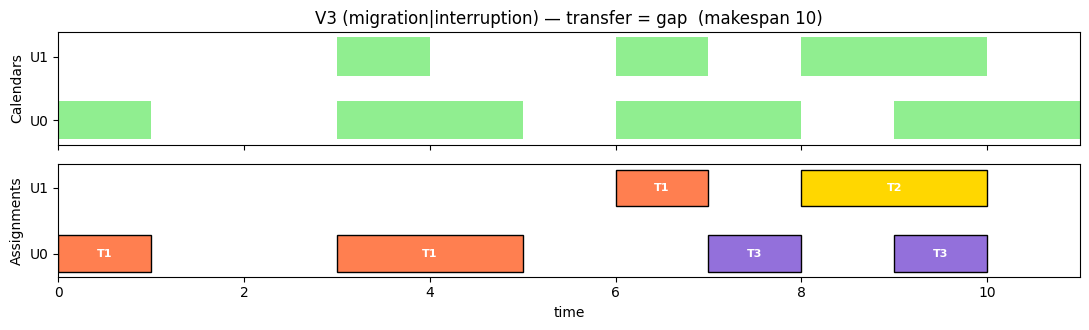

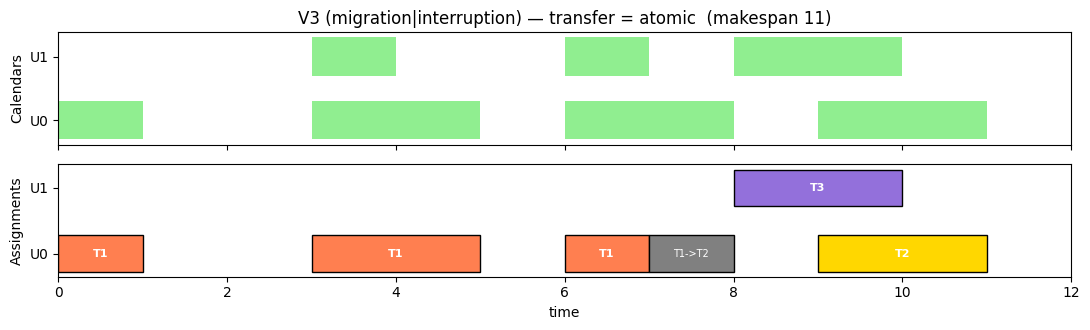

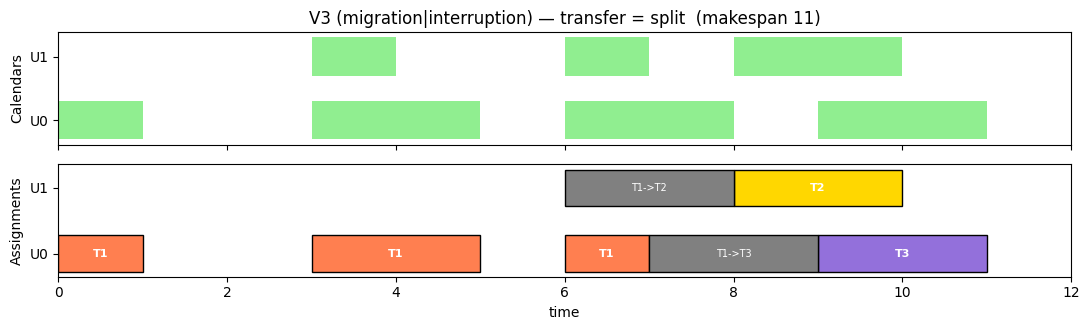

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

_TCOL = ['steelblue', 'coral', 'gold', 'mediumpurple', 'darkcyan', 'sandybrown']

def plot_combo(result, title, horizon=None):
    """Gantt: calendars on top, assignments below; gray = an actual transfer
    (labelled Ti->Tj). Calendar pauses are left empty."""
    sched, xfers = result['schedule'], result['transfers'] or []
    units = inst['units']
    if horizon is None:
        horizon = max([t['end'] for t in sched] + [e for _, _, e in
                      [(0, 0, x['end']) for x in xfers]] + [1]) + 1
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 3.4), sharex=True)
    # calendars
    for lane, (uid, steps) in enumerate(units):
        for i, (t, v) in enumerate(steps):
            end = steps[i + 1][0] if i + 1 < len(steps) else horizon
            if v > 0:
                ax0.barh(lane, end - t, left=t, height=0.6, color='lightgreen')
    # assignments: working parts of tasks (omit pauses) + gray transfers
    def segs_of(t):
        if t.get('segments'):
            return [(s['start'], s['end'], s['resources']) for s in t['segments']]
        if t.get('resources') and t['end'] > t['start']:
            return [(t['start'], t['end'], t['resources'])]
        return []
    for t in sched:
        for s, e, res in segs_of(t):
            for u in res:
                lane = [l for l, (uu, _) in enumerate(units) if uu == u][0]
                for ss, ee, working in _work_breaks(s, e, [u], res_map):
                    if working:
                        ax1.barh(lane, ee - ss, left=ss, height=0.55,
                                 color=_TCOL[t['id'] % len(_TCOL)], edgecolor='black')
                        ax1.text((ss + ee) / 2, lane, f"T{t['id']}", ha='center',
                                 va='center', color='white', fontsize=8, fontweight='bold')
    for x in xfers:
        lane = [l for l, (uu, _) in enumerate(units) if uu == x['unit']][0]
        ax1.barh(lane, x['end'] - x['start'], left=x['start'], height=0.55,
                 color='gray', edgecolor='black')
        ax1.text((x['start'] + x['end']) / 2, lane,
                 f"T{x['from_task']}->T{x['to_task']}", ha='center', va='center',
                 color='white', fontsize=7)
    for ax, lab in ((ax0, 'Calendars'), (ax1, 'Assignments')):
        ax.set_yticks(range(len(units)))
        ax.set_yticklabels([f"U{u}" for u, _ in units])
        ax.set_ylabel(lab); ax.set_xlim(0, horizon)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax1.set_xlabel('time'); ax0.set_title(title)
    plt.tight_layout(); plt.show()

for s in SEMANTICS:
    r = solve_optal('V3', s, time_limit=10)
    plot_combo(r, f"V3 (migration|interruption) — transfer = {s}  (makespan {r['makespan']})")


## Additional Resources

- **RCPSP-TT base notebook**: [`rcpsptt.ipynb`](rcpsptt.ipynb)
- **RCPSP with calendars**: [`rcpsp_timeoffs.ipynb`](rcpsp_timeoffs.ipynb)
- **cpsolve framework** — all four solver models:
  - [`rcpsptt_cal/cal/models/`](../../../solver/cpsolve/src/cpsolve/problems/rcpsptt_cal/cal/models/)
  - [`rcpsptt_cal/cal_migration_nointerruption/models/`](../../../solver/cpsolve/src/cpsolve/problems/rcpsptt_cal/cal_migration_nointerruption/models/)
  - [`rcpsptt_cal/cal_nomigration_blockedinterruption/models/`](../../../solver/cpsolve/src/cpsolve/problems/rcpsptt_cal/cal_nomigration_blockedinterruption/models/)
  - [`rcpsptt_cal/cal_migration_interruption/models/`](../../../solver/cpsolve/src/cpsolve/problems/rcpsptt_cal/cal_migration_interruption/models/)
- **Data**: [`cpsolve/data/rcpsptt_cal/`](../../../solver/cpsolve/data/rcpsptt_cal/)
